# 🍛 FitAI — Optimized Food Classification (v2)
### ConvNeXt-Tiny · Class-Weighted Loss · MixUp · 3-Stage Fine-Tuning · TTA Ensemble

**What changed from Phase 1:**
- ❌ Removed: EfficientNet-B0, MobileNetV3 (weak architectures for small datasets)
- ✅ Added: ConvNeXt-Tiny as primary model (stronger pretrained features, better on <500 images)
- ✅ Added: Class-weighted loss (fixes imbalance)
- ✅ Added: MixUp augmentation (+1–2%)
- ✅ Added: 3-stage freeze/unfreeze with layer-wise LR decay
- ✅ Added: Dataset diagnosis (noisy sample detection, class similarity)
- ✅ Added: Test-Time Augmentation (TTA)
- ✅ Added: Temperature-calibrated ensemble
- ✅ Fixed: Augmentation pipeline (food-safe, no vertical flips, no blur)
- ✅ Fixed: Evaluation uses balanced accuracy + macro F1, not just flat accuracy

> ⚠️ Runtime → Change Runtime Type → **T4 GPU** before running

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/FitAI/1000_images.zip'

## Step 0: Mount Google Drive

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/FitAI/1000_images.zip'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = '/content/drive/MyDrive/FitAI/models_v2'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ Drive mounted. Models will be saved to: {SAVE_DIR}')

Mounted at /content/drive
✅ Drive mounted. Models will be saved to: /content/drive/MyDrive/FitAI/models_v2


## Step 1: Install Dependencies

In [4]:
!pip install -q timm torchmetrics scikit-learn seaborn
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 29.7 MB/s eta 0:00:00
✅ Dependencies installed


In [5]:
import zipfile, os

ZIP_PATH = '/content/drive/MyDrive/FitAI/1000_images.zip'

size_mb = os.path.getsize(ZIP_PATH) / 1e6
print(f"Zip size: {size_mb:.1f} MB")
print(f"\nFirst 20 files inside zip:")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    names = z.namelist()
    print(f"Total files: {len(names)}")
    for f in names[:20]:
        print(f"  {f}")

Zip size: 10067.1 MB

First 20 files inside zip:
Total files: 202125
  food-101.zip
  food-101/__MACOSX/._food-101
  food-101/__MACOSX/food-101/._.DS_Store
  food-101/__MACOSX/food-101/._README.txt
  food-101/__MACOSX/food-101/._images
  food-101/__MACOSX/food-101/._license_agreement.txt
  food-101/__MACOSX/food-101/._meta
  food-101/__MACOSX/food-101/images/._.DS_Store
  food-101/__MACOSX/food-101/images/._apple_pie
  food-101/__MACOSX/food-101/images/._baby_back_ribs
  food-101/__MACOSX/food-101/images/._baklava
  food-101/__MACOSX/food-101/images/._beef_carpaccio
  food-101/__MACOSX/food-101/images/._beef_tartare
  food-101/__MACOSX/food-101/images/._beet_salad
  food-101/__MACOSX/food-101/images/._beignets
  food-101/__MACOSX/food-101/images/._bibimbap
  food-101/__MACOSX/food-101/images/._bread_pudding
  food-101/__MACOSX/food-101/images/._breakfast_burrito
  food-101/__MACOSX/food-101/images/._bruschetta
  food-101/__MACOSX/food-101/images/._caesar_salad


In [6]:
import zipfile

ZIP_PATH = '/content/drive/MyDrive/FitAI/1000_images.zip'

# Indian/relevant classes we care about
WANT = ['burger', 'pizza', 'fried_rice', 'rice', 'dosa', 'idli',
        'samosa', 'naan', 'biryani', 'omelette', 'egg', 'roti',
        'chicken', 'curry', 'sandwich', 'french_fries', 'ice_cream',
        'waffle', 'hot_dog', 'spring_roll', 'cheesecake']

print("Checking Food-101 classes...\n")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    names = z.namelist()
    # Get unique top-level class folders
    classes = set()
    for f in names:
        parts = f.split('/')
        # class folders are at: food-101/images/CLASS_NAME/
        if len(parts) >= 4 and parts[1] == 'food-101' and parts[2] == 'images':
            if parts[3] and not parts[3].startswith('.') and not parts[3].startswith('_'):
                classes.add(parts[3])

print(f"Total classes in Food-101: {len(classes)}")
print(f"\nClasses useful for FitAI:")
for c in sorted(classes):
    match = any(w in c for w in WANT)
    if match:
        print(f"  ✅ {c}")

print(f"\nAll classes:")
for c in sorted(classes):
    print(f"  {c}")

Checking Food-101 classes...

Total classes in Food-101: 101

Classes useful for FitAI:
  ✅ cheesecake
  ✅ chicken_curry
  ✅ chicken_quesadilla
  ✅ chicken_wings
  ✅ club_sandwich
  ✅ deviled_eggs
  ✅ eggs_benedict
  ✅ french_fries
  ✅ fried_rice
  ✅ grilled_cheese_sandwich
  ✅ hamburger
  ✅ hot_dog
  ✅ ice_cream
  ✅ lobster_roll_sandwich
  ✅ omelette
  ✅ pizza
  ✅ pulled_pork_sandwich
  ✅ samosa
  ✅ spring_rolls
  ✅ waffles

All classes:
  apple_pie
  baby_back_ribs
  baklava
  beef_carpaccio
  beef_tartare
  beet_salad
  beignets
  bibimbap
  bread_pudding
  breakfast_burrito
  bruschetta
  caesar_salad
  cannoli
  caprese_salad
  carrot_cake
  ceviche
  cheese_plate
  cheesecake
  chicken_curry
  chicken_quesadilla
  chicken_wings
  chocolate_cake
  chocolate_mousse
  churros
  clam_chowder
  club_sandwich
  crab_cakes
  creme_brulee
  croque_madame
  cup_cakes
  deviled_eggs
  donuts
  dumplings
  edamame
  eggs_benedict
  escargots
  falafel
  filet_mignon
  fish_and_chips
  foie_

In [7]:
import zipfile, os, shutil

ZIP_PATH     = '/content/drive/MyDrive/FitAI/1000_images.zip'
EXTRACT_DIR  = '/content/drive/MyDrive/FitAI/food101_extracted'

# Only extract these — ignore the other 89 classes
FOOD101_KEEP = {
    'chicken_curry':  'chicken_curry',
    'fried_rice':     'fried_rice',
    'french_fries':   'french_fries',
    'hamburger':      'burger',
    'hot_dog':        'hot_dog',
    'ice_cream':      'ice_cream',
    'omelette':       'egg_omelette',
    'pizza':          'pizza',
    'samosa':         'samosa',
    'spring_rolls':   'spring_rolls',
    'waffles':        'waffle',
}

os.makedirs(EXTRACT_DIR, exist_ok=True)
print(f"Extracting only {len(FOOD101_KEEP)} relevant classes from Food-101...")
print("(skipping other 89 classes — saves time and space)\n")

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    all_files = z.namelist()

    for food101_name, canonical in FOOD101_KEEP.items():
        # Files are at: food-101/food-101/images/CLASS/xxxx.jpg
        prefix = f'food-101/images/{food101_name}/'
        matching = [f for f in all_files
                    if f.startswith(prefix) and f.endswith('.jpg')]

        if not matching:
            # try alternate path
            prefix = f'food-101/food-101/images/{food101_name}/'
            matching = [f for f in all_files
                       if f.startswith(prefix) and f.endswith('.jpg')]

        dst = os.path.join(EXTRACT_DIR, canonical)
        os.makedirs(dst, exist_ok=True)

        # Only extract up to 100 images
        extracted = 0
        for f in matching[:100]:
            filename = os.path.basename(f)
            if not filename:
                continue
            with z.open(f) as src_file:
                with open(os.path.join(dst, f'food101_{filename}'), 'wb') as dst_file:
                    dst_file.write(src_file.read())
            extracted += 1

        status = "✅" if extracted > 0 else "❌ not found"
        print(f"  {food101_name:<25} → {canonical:<20} {extracted} images  {status}")

print(f"\n✅ Done! Extracted to {EXTRACT_DIR}")

Extracting only 11 relevant classes from Food-101...
(skipping other 89 classes — saves time and space)

  chicken_curry             → chicken_curry        100 images  ✅
  fried_rice                → fried_rice           100 images  ✅
  french_fries              → french_fries         100 images  ✅
  hamburger                 → burger               100 images  ✅
  hot_dog                   → hot_dog              100 images  ✅
  ice_cream                 → ice_cream            100 images  ✅
  omelette                  → egg_omelette         100 images  ✅
  pizza                     → pizza                100 images  ✅
  samosa                    → samosa               100 images  ✅
  spring_rolls              → spring_rolls         100 images  ✅
  waffles                   → waffle               100 images  ✅

✅ Done! Extracted to /content/drive/MyDrive/FitAI/food101_extracted


## Step 2: Upload Dataset
Dataset: https://www.kaggle.com/datasets/iamsouravbanerjee/indian-food-images-dataset

Download the zip from Kaggle → upload it below.

In [ ]:
# import zipfile, os

# # ── Paths ─────────────────────────────────────────────────────────────────────
# ZIP_PATH    = '/content/drive/MyDrive/FitAI/archive.zip'
# EXTRACT_DIR = '/content/drive/MyDrive/FitAI/kaggle_extracted'

# # Only extracts once — safe to re-run every session
# if not os.path.exists(EXTRACT_DIR) or len(os.listdir(EXTRACT_DIR)) == 0:
#     os.makedirs(EXTRACT_DIR, exist_ok=True)
#     print("Extracting zip... (2-3 min, only happens once ever)")
#     with zipfile.ZipFile(ZIP_PATH, 'r') as z:
#         z.extractall(EXTRACT_DIR)
#     print("✅ Done extracting")
# else:
#     print("✅ Already extracted — skipping")

# # Auto-find actual class folders inside the zip
# KAGGLE_ROOT = EXTRACT_DIR
# for root, dirs, files in os.walk(EXTRACT_DIR):
#     if len(dirs) > 10:
#         KAGGLE_ROOT = root
#         break

# print(f"📁 Kaggle root: {KAGGLE_ROOT}")
# print(f"   {len(os.listdir(KAGGLE_ROOT))} classes found")

✅ Already extracted — skipping
📁 Kaggle root: /content/drive/MyDrive/FitAI/kaggle_extracted/Indian Food Images/Indian Food Images
   80 classes found


In [ ]:
# import os

# # Find where the actual image folders are
# for root, dirs, files in os.walk('/content/indian_food'):
#     if dirs:
#         print(f'Found folders at: {root}')
#         print(f'Classes: {sorted(dirs)[:10]}... ({len(dirs)} total)')
#         break

## Step 3: Filter to Mess-Relevant Classes

In [27]:
# import os

# # ── Check 1: Did extraction work? ────────────────────────────────────────────
# EXTRACT_DIR = '/content/drive/MyDrive/FitAI/kaggle_extracted'
# print("=== KAGGLE EXTRACTION CHECK ===")
# if not os.path.exists(EXTRACT_DIR):
#     print("❌ kaggle_extracted folder doesn't exist — Cell 6 didn't run properly")
# else:
#     contents = os.listdir(EXTRACT_DIR)
#     print(f"✅ Exists | Contents: {contents[:10]}")

#     # Walk to find actual class folders
#     for root, dirs, files in os.walk(EXTRACT_DIR):
#         if len(dirs) > 5:
#             print(f"\n📁 Found class folders at: {root}")
#             print(f"   Sample classes: {sorted(dirs)[:8]}")
#             print(f"   Total folders: {len(dirs)}")
#             break

# # ── Check 2: Did your photos folder load? ────────────────────────────────────
# print("\n=== YOUR PHOTOS CHECK ===")
# YOUR_PHOTOS = '/content/drive/MyDrive/FitAI_ImageDataset'
# if not os.path.exists(YOUR_PHOTOS):
#     print(f"❌ Not found at: {YOUR_PHOTOS}")
#     print("   Check exact folder name in Drive")
# else:
#     folders = [f for f in os.listdir(YOUR_PHOTOS)
#                if os.path.isdir(os.path.join(YOUR_PHOTOS, f))]
#     print(f"✅ Found | {len(folders)} folders: {folders}")

# # ── Check 3: What is KAGGLE_ROOT set to right now? ───────────────────────────
# print("\n=== KAGGLE_ROOT VARIABLE CHECK ===")
# try:
#     print(f"KAGGLE_ROOT = '{KAGGLE_ROOT}'")
#     if os.path.exists(KAGGLE_ROOT):
#         print(f"✅ Path exists | Contents: {os.listdir(KAGGLE_ROOT)[:5]}")
#     else:
#         print("❌ Path does not exist")
# except NameError:
#     print("❌ KAGGLE_ROOT variable not set — Cell 6 didn't run or crashed")

=== KAGGLE EXTRACTION CHECK ===
✅ Exists | Contents: ['Indian Food Images', 'List of Indian Foods.txt']

📁 Found class folders at: /content/drive/MyDrive/FitAI/kaggle_extracted/Indian Food Images/Indian Food Images
   Sample classes: ['adhirasam', 'aloo_gobi', 'aloo_matar', 'aloo_methi', 'aloo_shimla_mirch', 'aloo_tikki', 'anarsa', 'ariselu']
   Total folders: 80

=== YOUR PHOTOS CHECK ===
❌ Not found at: /content/drive/MyDrive/FitAI_ImageDataset
   Check exact folder name in Drive

=== KAGGLE_ROOT VARIABLE CHECK ===
KAGGLE_ROOT = '/content/drive/MyDrive/FitAI/kaggle_extracted/Indian Food Images/Indian Food Images'
✅ Path exists | Contents: ['adhirasam', 'aloo_gobi', 'aloo_matar', 'aloo_methi', 'aloo_shimla_mirch']


In [28]:
import zipfile, os, shutil

ZIP_PATH    = '/content/drive/MyDrive/FitAI/archive.zip'
EXTRACT_DIR = '/content/drive/MyDrive/FitAI/kaggle_extracted'

# Clear the empty folder and re-extract
shutil.rmtree(EXTRACT_DIR, ignore_errors=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f"Zip exists: {os.path.exists(ZIP_PATH)}")
print(f"Zip size: {os.path.getsize(ZIP_PATH) / 1e6:.1f} MB")

print("\nExtracting... (takes 2-3 min)")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Walk and find actual class folders
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len(dirs) > 10:
        print(f"\n✅ Classes found at: {root}")
        print(f"   {len(dirs)} classes: {sorted(dirs)[:6]}...")
        KAGGLE_ROOT = root
        break
else:
    print("\n❌ Still no class folders found — check zip contents below:")
    for root, dirs, files in os.walk(EXTRACT_DIR):
        print(f"  {root} → dirs:{dirs[:3]} files:{len(files)}")

Zip exists: True
Zip size: 371.8 MB

Extracting... (takes 2-3 min)

✅ Classes found at: /content/drive/MyDrive/FitAI/kaggle_extracted/Indian Food Images/Indian Food Images
   80 classes: ['adhirasam', 'aloo_gobi', 'aloo_matar', 'aloo_methi', 'aloo_shimla_mirch', 'aloo_tikki']...


In [ ]:
# Scan your entire FitAI folder to find the image dataset
BASE = '/content/drive/MyDrive'

print("=== Everything in MyDrive/FitAI ===")
fitai_path = os.path.join(BASE, 'FitAI')
for item in os.listdir(fitai_path):
    full = os.path.join(fitai_path, item)
    kind = "📁" if os.path.isdir(full) else "📄"
    print(f"  {kind} {item}")

print("\n=== Everything directly in MyDrive ===")
for item in os.listdir(BASE):
    full = os.path.join(BASE, item)
    if os.path.isdir(full):
        print(f"  📁 {item}")

=== Everything in MyDrive/FitAI ===
  📁 models
  📄 FitAI_Phase1_Training.ipynb
  📁 models_v2
  📁 FitAI_ImageDataset
  📄 FitAI_Phase1_Optimized_v2.ipynb
  📄 archive.zip
  📁 kaggle_extracted

=== Everything directly in MyDrive ===
  📁 Colab Notebooks
  📁 KarnatakaTrip
  📁 Sanjam's best
  📁 Subhang's best
  📁 Aritro's best
  📁 DSLR'S best
  📁 Ranjith's best
  📁 Koraput Trip-11 25
  📁 FitAI


In [8]:
import os, shutil, random
import numpy as np

YOUR_PHOTOS   = '/content/drive/MyDrive/FitAI/FitAI_ImageDataset'
FILTERED_DIR  = '/content/mess_dataset'
MAX_PER_CLASS = 100

# ── Paths for both Kaggle datasets ────────────────────────────────────────────
KAGGLE_SWEETS_ROOT = '/content/drive/MyDrive/FitAI/kaggle_extracted'  # already have this
FOOD101_ROOT       = '/content/drive/MyDrive/FitAI/food101_extracted'  # coming soon

# ── What the SWEETS dataset has that's useful ─────────────────────────────────
SWEETS_MAP = {
    'aloo_gobi':             'aloo_gobi',
    'aloo_matar':            'aloo_matar',
    'bhindi_masala':         'bhindi_masala',
    'biryani':               'biryani',
    'butter_chicken':        'butter_chicken',
    'chana_masala':          'chole',
    'chapati':               'chapati',
    'dal_makhani':           'dal_makhani',
    'dal_tadka':             'dal_fry',
    'gajar_ka_halwa':        'halwa',
    'gulab_jamun':           'gulab_jamun',
    'kadai_paneer':          'paneer_dish',
    'maach_jhol':            'odia_fish_curry',   # Tier 4 bonus!
    'naan':                  'naan',
    'palak_paneer':          'paneer_dish',
    'paneer_butter_masala':  'paneer_dish',
    'pithe':                 'pitha',              # Tier 4 bonus!
    'poha':                  'poha',
    'rasgulla':              'rasgulla',
}

# ── What Food-101 has that's useful ──────────────────────────────────────────
FOOD101_MAP = {
    'burger':                'burger',
    'pizza':                 'pizza',
    'rice':                  'rice',
    'idli':                  'idli',              # Food-101 has this
    'dosa':                  'dosa',              # Food-101 has this
    'samosa':                'samosa',
    'fried_rice':            'fried_rice',
    'chicken_curry':         'chicken_curry',
    'egg_omelette':          'egg_omelette',
    'pav_bhaji':             'pav_bhaji',
    'chole':                 'chole',
    'upma':                  'upma',
    'khichdi':               'khichdi',
    'jeera_rice':            'jeera_rice',
    'puri':                  'puri',
    'naan':                  'naan',
    'sambar':                'sambhar',
    'rajma':                 'rajma',
    'dal_fry':               'dal_fry',
    'aloo_matar':            'aloo_matar',
    'baingan_bharta':        'baingan_bharta',
    'mixed_veg':             'mixed_veg',
    'shawarma':              'shawarma',
    'biryani':               'biryani',
}

# ── Your self-collected photos ────────────────────────────────────────────────
YOUR_NAME_MAP = {
    'IDLI':              'idli',
    'DOSA':              'dosa',
    'Puri':              'puri',
    'Egg':               'egg_omelette',
    'Salad':             'salad',
    'biryani':           'biryani',
    'Paneer_Biryani':    'biryani',
    'Chicken_Biryani':   'biryani',
    'Burger':            'burger',
    'Pizza':             'pizza',
    'Shwarama':          'shawarma',
    'Ghoogni':           'ghuguni',
    'ghuguni':           'ghuguni',
    'Vada':              'vada',
    'Pakodi/Manchurian': 'pakodi_manchurian',
    'pakodi_manchurian': 'pakodi_manchurian',
    'Rice':              'rice',
    'Roti':              'chapati',
    'Soyabean':          'soyabean',
    'Paneer_curry':      'paneer_dish',
    'paneer_dish':       'paneer_dish',
    'MixVeg':            'mixed_veg',
    'Besan_Curry':       'besan_curry',
    'Chicken curry':     'chicken_curry',
    'Daal':              'dal_fry',
    'dal':               'dal_fry',
    'Gobi_Curry':        'aloo_gobi',
}

# ── Helper: copy images from a source folder into destination ─────────────────
def copy_images(src, dst, prefix, limit=MAX_PER_CLASS):
    os.makedirs(dst, exist_ok=True)
    imgs = [f for f in os.listdir(src)
            if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    random.shuffle(imgs)

    # Check how many slots are left (respect MAX_PER_CLASS across all sources)
    existing = len([f for f in os.listdir(dst)
                    if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
    slots = max(0, limit - existing)
    imgs = imgs[:slots]

    for img in imgs:
        shutil.copy(os.path.join(src, img),
                    os.path.join(dst, f'{prefix}_{img}'))
    return len(imgs)

# ── Helper: find actual class folder root inside extracted zip ────────────────
def find_root(base):
    if not os.path.exists(base):
        return None
    for root, dirs, files in os.walk(base):
        if len(dirs) > 5:
            return root
    return base

# ── Build merged dataset ──────────────────────────────────────────────────────
if os.path.exists(FILTERED_DIR):
    shutil.rmtree(FILTERED_DIR)
random.seed(42)

stats = {}

# 1. Pull from sweets Kaggle dataset
sweets_root = find_root(KAGGLE_SWEETS_ROOT)
if sweets_root:
    print(f"📦 Sweets dataset found at: {sweets_root}")
    sweets_folders = {
        f.lower().replace(' ','_').replace('-','_'): f
        for f in os.listdir(sweets_root)
        if os.path.isdir(os.path.join(sweets_root, f))
    }
    for key, canonical in SWEETS_MAP.items():
        matched = next((v for k, v in sweets_folders.items()
                        if key in k or k in key), None)
        if not matched:
            continue
        src = os.path.join(sweets_root, matched)
        dst = os.path.join(FILTERED_DIR, canonical)
        n = copy_images(src, dst, prefix='sweets')
        stats.setdefault(canonical, {'sweets':0, 'food101':0, 'yours':0})
        stats[canonical]['sweets'] += n
else:
    print("⚠️ Sweets dataset not found — skipping")

# 2. Pull from Food-101 (only if already downloaded)
food101_root = find_root(FOOD101_ROOT)
if food101_root:
    print(f"📦 Food-101 found at: {food101_root}")
    food101_folders = {
        f.lower().replace(' ','_').replace('-','_'): f
        for f in os.listdir(food101_root)
        if os.path.isdir(os.path.join(food101_root, f))
    }
    for key, canonical in FOOD101_MAP.items():
        matched = next((v for k, v in food101_folders.items()
                        if key in k or k in key), None)
        if not matched:
            continue
        src = os.path.join(food101_root, matched)
        dst = os.path.join(FILTERED_DIR, canonical)
        n = copy_images(src, dst, prefix='food101')
        stats.setdefault(canonical, {'sweets':0, 'food101':0, 'yours':0})
        stats[canonical]['food101'] += n
else:
    print("⏳ Food-101 not extracted yet — will add after download completes")

# 3. Add your self-collected photos (always highest priority — added last)
if os.path.exists(YOUR_PHOTOS):
    print(f"📸 Your photos found at: {YOUR_PHOTOS}")
    for your_name, canonical in YOUR_NAME_MAP.items():
        src = os.path.join(YOUR_PHOTOS, your_name)
        if not os.path.exists(src):
            continue
        dst = os.path.join(FILTERED_DIR, canonical)
        imgs = [f for f in os.listdir(src)
                if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
        os.makedirs(dst, exist_ok=True)
        for img in imgs:
            # Your photos always get copied regardless of cap — they're gold
            shutil.copy(os.path.join(src, img),
                        os.path.join(dst, f'yours_{img}'))
        stats.setdefault(canonical, {'sweets':0, 'food101':0, 'yours':0})
        stats[canonical]['yours'] += len(imgs)
else:
    print(f"⚠️ Your photos not found at {YOUR_PHOTOS}")

# ── Print summary ─────────────────────────────────────────────────────────────
print(f"\n{'Class':<25} {'Sweets':>8} {'F-101':>7} {'Yours':>7} {'Total':>7}  Status")
print("─" * 72)

CLASSES = sorted(os.listdir(FILTERED_DIR))
NUM_CLASSES = len(CLASSES)

for cls in CLASSES:
    s = stats.get(cls, {})
    sw = s.get('sweets', 0)
    f1 = s.get('food101', 0)
    yo = s.get('yours', 0)
    t  = sw + f1 + yo
    status = "✅" if t >= 60 else ("⚠️  need more" if t >= 20 else "❌  too few")
    star = " ⭐" if yo > 0 else ""
    print(f"  {cls:<25} {sw:>8} {f1:>7} {yo:>7} {t:>7}  {status}{star}")

print("─" * 72)
print(f"\n✅ {NUM_CLASSES} classes ready at {FILTERED_DIR}")
print("⭐ = has your KIIT mess photos")

📦 Sweets dataset found at: /content/drive/MyDrive/FitAI/kaggle_extracted/Indian Food Images/Indian Food Images
📦 Food-101 found at: /content/drive/MyDrive/FitAI/food101_extracted
📸 Your photos found at: /content/drive/MyDrive/FitAI/FitAI_ImageDataset

Class                       Sweets   F-101   Yours   Total  Status
────────────────────────────────────────────────────────────────────────
  aloo_gobi                       50       0      20      70  ✅ ⭐
  aloo_matar                      50       0       0      50  ⚠️  need more
  besan_curry                      0       0      49      49  ⚠️  need more ⭐
  bhindi_masala                   50       0       0      50  ⚠️  need more
  biryani                         50       0       2      52  ⚠️  need more ⭐
  burger                           0     100       0     100  ✅
  butter_chicken                  50       0       0      50  ⚠️  need more
  chapati                         50       0      22      72  ✅ ⭐
  chicken_curry             

In [9]:
!pip install icrawler -q

from icrawler.builtin import GoogleImageCrawler
import os

FILTERED_DIR = '/content/mess_dataset'
TARGET = 60  # minimum we want per class

# Query tuned per class — bad queries = wrong images
SCRAPE_TARGETS = {
    # ❌ Critical — 0 images
    'dosa':          'dosa south indian breakfast crispy',
    'idli':          'idli sambar plate south indian',
    'puri':          'puri bhaji indian breakfast puffed bread',
    'ghuguni':       'ghuguni odisha street food chickpea curry',
    'salad':         'indian vegetable salad kachumber plate',
    'vada':          'medu vada south indian crispy',
    'shawarma':      'shawarma wrap roll street food',
    'mixed_veg':     'mix vegetable curry indian food',
    'soyabean':      'soya chunks curry indian meal',

    # ⚠️ Need more — top up to 60
    'aloo_matar':    'aloo matar potato peas curry indian',
    'besan_curry':   'besan kadhi curry indian food',
    'bhindi_masala': 'bhindi masala okra curry indian',
    'biryani':       'biryani rice indian restaurant',
    'butter_chicken':'butter chicken murgh makhani indian',
    'chole':         'chole chana masala chickpea curry',
    'dal_makhani':   'dal makhani black lentil curry',
    'gulab_jamun':   'gulab jamun indian sweet dessert',
    'halwa':         'gajar halwa carrot indian sweet',
    'naan':          'naan bread indian tandoor',
    'odia_fish_curry':'odia fish curry odisha style',
    'pitha':         'pitha odisha rice cake festival',
    'poha':          'poha flattened rice indian breakfast',
    'rasgulla':      'rasgulla white spongy bengali sweet',
}

print(f"{'Class':<20} {'Have':>5} {'Need':>5} {'Action'}")
print("─" * 50)

for class_name, query in SCRAPE_TARGETS.items():
    dst = os.path.join(FILTERED_DIR, class_name)
    os.makedirs(dst, exist_ok=True)

    existing = [f for f in os.listdir(dst)
                if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    have = len(existing)

    if have >= TARGET:
        print(f"  {class_name:<20} {have:>5} {0:>5}  ✅ skip")
        continue

    needed = TARGET - have
    print(f"  {class_name:<20} {have:>5} {needed:>5}  🔍 scraping...")

    try:
        crawler = GoogleImageCrawler(
            storage={'root_dir': dst},
            log_level=50  # silent
        )
        crawler.crawl(
            keyword=query,
            max_num=needed,
            filters={'size': 'medium'}
        )

        # Rename to avoid collisions
        for f in os.listdir(dst):
            if not any(f.startswith(p) for p in
                       ['scraped_','yours_','kaggle_','sweets_','food101_']):
                old = os.path.join(dst, f)
                new = os.path.join(dst, f'scraped_{f}')
                try:
                    os.rename(old, new)
                except:
                    pass

        final = len([f for f in os.listdir(dst)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"  {'':20} {'':>5} {'':>5}  → now has {final} images")

    except Exception as e:
        print(f"  {'':20} {'':>5} {'':>5}  ⚠️ failed: {e}")

# ── Final count after scraping ────────────────────────────────────────────────
print("\n" + "─" * 55)
print("FINAL DATASET STATUS:")
print(f"{'Class':<25} {'Total':>7}  Status")
print("─" * 55)
total_imgs = 0
for cls in sorted(os.listdir(FILTERED_DIR)):
    path = os.path.join(FILTERED_DIR, cls)
    if not os.path.isdir(path):
        continue
    n = len([f for f in os.listdir(path)
             if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
    total_imgs += n
    status = "✅" if n >= 60 else ("⚠️" if n >= 30 else "❌")
    print(f"  {cls:<25} {n:>7}  {status}")
print("─" * 55)
print(f"  {'TOTAL':<25} {total_imgs:>7}")
print("\n⚠️  After scraping — manually delete bad images from each folder")
print("   Cartoons, wrong dishes, duplicates — takes 5 min, worth it")

Class                 Have  Need Action
──────────────────────────────────────────────────
  dosa                     0    60  🔍 scraping...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


                                    → now has 0 images
  idli                     0    60  🔍 scraping...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


                                    → now has 0 images
  puri                     0    60  🔍 scraping...


...

                                    → now has 50 images
  poha                    50    10  🔍 scraping...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


                                    → now has 50 images
  rasgulla                50    10  🔍 scraping...


Exception in thread parser-001:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/icrawler/parser.py", line 93, in worker_exec
    for task in self.parse(response, **kwargs):
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: 'NoneType' object is not iterable


                                    → now has 50 images

───────────────────────────────────────────────────────
FINAL DATASET STATUS:
Class                       Total  Status
───────────────────────────────────────────────────────
  aloo_gobi                      70  ✅
  aloo_matar                     50  ⚠️
  besan_curry                    49  ⚠️
  bhindi_masala                  50  ⚠️
  biryani                        52  ⚠️
  burger                        100  ✅
  butter_chicken                 50  ⚠️
  chapati                        72  ✅
  chicken_curry                 100  ✅
  chole                          50  ⚠️
  dal_fry                        76  ✅
  dal_makhani                    50  ⚠️
  dosa                            0  ❌
  egg_omelette                  110  ✅
  fried_rice                    100  ✅
  ghuguni                         3  ❌
  gulab_jamun                    50  ⚠️
  halwa                          50  ⚠️
  idli                            0  ❌
  mixed_veg      

In [10]:
!pip install icrawler -q

from icrawler.builtin import BingImageCrawler
import os

FILTERED_DIR = '/content/mess_dataset'
TARGET = 60

SCRAPE_TARGETS = {
    'dosa':           'dosa south indian breakfast',
    'idli':           'idli sambar plate south indian',
    'puri':           'puri bread indian breakfast puffed',
    'ghuguni':        'ghuguni odisha chickpea curry',
    'salad':          'indian kachumber salad plate',
    'vada':           'medu vada south indian',
    'shawarma':       'shawarma wrap street food',
    'mixed_veg':      'mix vegetable curry indian',
    'soyabean':       'soya chunks curry indian',
    'aloo_matar':     'aloo matar curry indian',
    'besan_curry':    'besan kadhi curry',
    'bhindi_masala':  'bhindi masala okra curry',
    'biryani':        'biryani rice indian',
    'butter_chicken': 'butter chicken indian',
    'chole':          'chole chana masala',
    'dal_makhani':    'dal makhani indian',
    'gulab_jamun':    'gulab jamun sweet',
    'halwa':          'gajar halwa indian sweet',
    'naan':           'naan bread indian',
    'odia_fish_curry':'odia fish curry',
    'pitha':          'pitha odisha rice cake',
    'poha':           'poha indian breakfast',
    'rasgulla':       'rasgulla bengali sweet',
}

print("Scraping with Bing...\n")

for class_name, query in SCRAPE_TARGETS.items():
    dst = os.path.join(FILTERED_DIR, class_name)
    os.makedirs(dst, exist_ok=True)

    existing = [f for f in os.listdir(dst)
                if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
    have = len(existing)

    if have >= TARGET:
        print(f"✅ {class_name}: {have} — skip")
        continue

    needed = TARGET - have
    print(f"🔍 {class_name}: have {have}, scraping {needed}...")

    try:
        crawler = BingImageCrawler(
            storage={'root_dir': dst},
            log_level=50
        )
        crawler.crawl(
            keyword=query,
            max_num=needed,
            filters={'size': 'medium'}
        )

        # Rename files
        for f in os.listdir(dst):
            if not any(f.startswith(p) for p in
                       ['scraped_','yours_','kaggle_','sweets_','food101_']):
                try:
                    os.rename(os.path.join(dst, f),
                              os.path.join(dst, f'scraped_{f}'))
                except:
                    pass

        final = len([f for f in os.listdir(dst)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])
        print(f"   → {final} total\n")

    except Exception as e:
        print(f"   ⚠️ failed: {e}\n")

# Final status
print("\nFINAL STATUS:")
print(f"{'Class':<25} {'Total':>7}  Status")
print("─" * 40)
for cls in sorted(os.listdir(FILTERED_DIR)):
    path = os.path.join(FILTERED_DIR, cls)
    if not os.path.isdir(path): continue
    n = len([f for f in os.listdir(path)
             if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
    status = "✅" if n >= 60 else ("⚠️" if n >= 30 else "❌")
    print(f"  {cls:<25} {n:>7}  {status}")

Scraping with Bing...

🔍 dosa: have 0, scraping 60...


ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/2046550697/photo/dosa-south-indian-breakfast.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/1374666267/photo/masala-dosa-south-indian-breakfast.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/1374665744/photo/rava-dosa-south-indian-breakfast.jpg
ERROR:downloader:Response status code 400, file https://media.istockphoto.com/id/2134459545/vector/masala-dosa-south-indian-breakfast-crepes.jpg


   → 59 total

🔍 idli: have 0, scraping 60...


ERROR:downloader:Response status code 403, file https://png.pngtree.com/thumb_back/fh260/background/20230331/pngtree-south-indian-food-idli-idlis-photo-image_2158345.jpg
ERROR:downloader:Response status code 403, file https://png.pngtree.com/thumb_back/fh260/background/20220117/pngtree-south-indian-rava-idli-with-sambar-and-chutney-photo-image_28873964.jpg
ERROR:downloader:Response status code 403, file https://png.pngtree.com/thumb_back/fh260/background/20220117/pngtree-south-indian-rava-idli-with-sambar-and-chutney-photo-image_28873960.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/thumbnails/016/585/467/small_2x/mini-idli-or-idlies-with-sambar-and-coconut-chutney-south-indian-breakfast-free-photo.jpg


   → 54 total

🔍 puri: have 0, scraping 60...


...

   → 60 total

🔍 chole: have 50, scraping 10...
   → 60 total

🔍 dal_makhani: have 50, scraping 10...
   → 60 total

🔍 gulab_jamun: have 50, scraping 10...


ERROR:downloader:Response status code 403, file https://c.ndtvimg.com/2019-05/5t1f6neg_gulab-jamun_625x300_16_May_19.jpg


   → 60 total

🔍 halwa: have 50, scraping 10...
   → 60 total

🔍 naan: have 50, scraping 10...
   → 60 total

🔍 odia_fish_curry: have 50, scraping 10...
   → 60 total

🔍 pitha: have 50, scraping 10...


ERROR:downloader:Response status code 403, file https://humanitiesacrossborders.org/sites/default/files/styles/ept_video_and_image_gallery/public/2024-04/dsc_0482.jpg
ERROR:downloader:Response status code 403, file https://humanitiesacrossborders.org/sites/default/files/styles/ept_video_and_image_gallery/public/2024-04/dsc_0489.jpg


   → 60 total

🔍 poha: have 50, scraping 10...
   → 60 total

🔍 rasgulla: have 50, scraping 10...
   → 60 total


FINAL STATUS:
Class                       Total  Status
────────────────────────────────────────
  aloo_gobi                      70  ✅
  aloo_matar                     60  ✅
  besan_curry                    60  ✅
  bhindi_masala                  60  ✅
  biryani                        60  ✅
  burger                        100  ✅
  butter_chicken                 60  ✅
  chapati                        72  ✅
  chicken_curry                 100  ✅
  chole                          60  ✅
  dal_fry                        76  ✅
  dal_makhani                    60  ✅
  dosa                           59  ⚠️
  egg_omelette                  110  ✅
  fried_rice                    100  ✅
  ghuguni                        58  ⚠️
  gulab_jamun                    60  ✅
  halwa                          60  ✅
  idli                           54  ⚠️
  mixed_veg                      60  ✅
  naan

In [ ]:
# def find_matching_classes(all_classes, mess_classes):
#     matched = {}
#     all_lower = {c.lower().replace(' ', '_').replace('-', '_'): c for c in all_classes}
#     for mess_cls in mess_classes:
#         mess_lower = mess_cls.lower()
#         if mess_lower in all_lower:
#             matched[mess_cls] = all_lower[mess_lower]
#         else:
#             for key, original in all_lower.items():
#                 if mess_lower in key or key in mess_lower:
#                     matched[mess_cls] = original
#                     break
#     return matched

# matched = find_matching_classes(all_classes, MESS_CLASSES)
# print(f'\n✅ Matched {len(matched)}/{len(MESS_CLASSES)} mess classes:')
# for mess, original in matched.items():
#     count = len(os.listdir(os.path.join(DATASET_ROOT, original)))
#     print(f'  {mess:30s} → {original:30s} ({count} images)')

# unmatched = [c for c in MESS_CLASSES if c not in matched]
# if unmatched:
#     print(f'\n⚠️  Unmatched (not in dataset): {unmatched}')

NameError: name 'all_classes' is not defined

In [ ]:
# # Build filtered dataset folder
# FILTERED_DIR = '/content/mess_dataset'

# if os.path.exists(FILTERED_DIR):
#     shutil.rmtree(FILTERED_DIR)

# # ── Copy all normal classes ───────────────────────────────────────────────────
# PANEER_SOURCES = ['palak_paneer', 'paneer_butter_masala', 'matar_paneer', 'kadai_paneer']

# for mess_name, original_name in matched.items():
#     if mess_name == 'paneer_dish':
#         continue  # handled separately below
#     src = os.path.join(DATASET_ROOT, original_name)
#     dst = os.path.join(FILTERED_DIR, mess_name)
#     shutil.copytree(src, dst)

# # ── Merge all paneer classes into one ────────────────────────────────────────
# # This is the key fix: 3 classes that confused each other become 1
# # Result: ~3-4x more training data for paneer, eliminates inter-paneer confusion
# paneer_dst = os.path.join(FILTERED_DIR, 'paneer_dish')
# os.makedirs(paneer_dst, exist_ok=True)

# paneer_copied = 0
# for source_class in PANEER_SOURCES:
#     # Find this class in the dataset (flexible match)
#     for original_name in os.listdir(DATASET_ROOT):
#         if source_class.lower().replace('_', '') in original_name.lower().replace('_', '').replace(' ', ''):
#             src_dir = os.path.join(DATASET_ROOT, original_name)
#             for img_file in os.listdir(src_dir):
#                 if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
#                     # Prefix filename with source class to avoid name collisions
#                     new_name = f"{source_class}_{img_file}"
#                     shutil.copy(
#                         os.path.join(src_dir, img_file),
#                         os.path.join(paneer_dst, new_name)
#                     )
#                     paneer_copied += 1

# print(f'paneer_dish: merged {paneer_copied} images from {PANEER_SOURCES}')

# # Final class list
# CLASSES = sorted(os.listdir(FILTERED_DIR))
# NUM_CLASSES = len(CLASSES)
# print(f'\n✅ Filtered dataset ready at {FILTERED_DIR}')
# print(f'Total classes: {NUM_CLASSES}')
# for cls in CLASSES:
#     count = len(os.listdir(os.path.join(FILTERED_DIR, cls)))
#     flag = ' ⭐ merged' if cls == 'paneer_dish' else ''
#     print(f'  {cls:<25} {count} images{flag}')
# # ```

# # ---

# ## That's it. Now just run all cells top to bottom.

# # **Nothing else changes.** Cell 13 (train/val split), Cell 15 (augmentation), Cell 18 (model), Cell 20 (training) — all stay exactly the same. `NUM_CLASSES` will automatically be one less (because 4 classes became 1), and every downstream cell just uses `CLASSES` and `NUM_CLASSES` so they adapt automatically.

# # **What you should see when Cell 11 runs:**
# # ```
# # paneer_dish: merged ~200-250 images from the 4 source classes
# # Total classes: 27  (was 28 before — 4 paneer → 1)
# #   paneer_dish    ~200 images  ⭐ merged
# #   gulab_jamun    ~100 images
# #   ...

SyntaxError: invalid syntax (3952077209.py, line 50)

In [31]:
# import os

# print(f"{'Class':<25} {'Images':>8}")
# print("─" * 36)
# empty = []
# for cls in sorted(os.listdir(FILTERED_DIR)):
#     path = os.path.join(FILTERED_DIR, cls)
#     imgs = [f for f in os.listdir(path)
#             if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))]
#     count = len(imgs)
#     flag = "  ❌ EMPTY" if count == 0 else ("  ⚠️" if count < 10 else "")
#     print(f"  {cls:<25} {count:>8}{flag}")
#     if count == 0:
#         empty.append(cls)

# print("─" * 36)
# print(f"\nTotal classes: {len(os.listdir(FILTERED_DIR))}")
# print(f"Empty classes: {empty}")

Class                       Images
────────────────────────────────────
  aloo_gobi                       70
  aloo_matar                      50
  besan_curry                     49
  bhindi_masala                   50
  biryani                         52
  burger                           0  ❌ EMPTY
  chapati                         72
  dal_fry                         76
  dosa                             0  ❌ EMPTY
  egg_omelette                    10
  ghuguni                          3  ⚠️
  gulab_jamun                     50
  idli                             0  ❌ EMPTY
  mixed_veg                       15
  naan                            50
  paneer_dish                    169
  poha                            50
  puri                            50
  rice                             1  ⚠️
  salad                            3  ⚠️
  shawarma                        15
  soyabean                        15
  vada                             4  ⚠️
──────────────────────────────────

In [32]:
import os, shutil, random
random.seed(42)

# ── Print ALL Kaggle folder names so we can see exact spelling ────────────────
print("All Kaggle folders:")
for f in sorted(os.listdir(KAGGLE_ROOT)):
    if os.path.isdir(os.path.join(KAGGLE_ROOT, f)):
        count = len(os.listdir(os.path.join(KAGGLE_ROOT, f)))
        print(f"  '{f}' ({count} images)")

All Kaggle folders:
  'adhirasam' (50 images)
  'aloo_gobi' (50 images)
  'aloo_matar' (50 images)
  'aloo_methi' (50 images)
  'aloo_shimla_mirch' (50 images)
  'aloo_tikki' (50 images)
  'anarsa' (50 images)
  'ariselu' (50 images)
  'bandar_laddu' (50 images)
  'basundi' (50 images)
  'bhatura' (50 images)
  'bhindi_masala' (50 images)
  'biryani' (50 images)
  'boondi' (50 images)
  'butter_chicken' (50 images)
  'chak_hao_kheer' (50 images)
  'cham_cham' (50 images)
  'chana_masala' (50 images)
  'chapati' (50 images)
  'chhena_kheeri' (50 images)
  'chicken_razala' (50 images)
  'chicken_tikka' (50 images)
  'chicken_tikka_masala' (50 images)
  'chikki' (50 images)
  'daal_baati_churma' (50 images)
  'daal_puri' (50 images)
  'dal_makhani' (50 images)
  'dal_tadka' (50 images)
  'dharwad_pedha' (50 images)
  'doodhpak' (50 images)
  'double_ka_meetha' (50 images)
  'dum_aloo' (50 images)
  'gajar_ka_halwa' (50 images)
  'gavvalu' (50 images)
  'ghevar' (50 images)
  'gulab_jamun'

## Step 4: Train / Val / Test Split (70 / 15 / 15)

In [11]:
import numpy as np
import random
from sklearn.model_selection import train_test_split

SPLIT_DIR = '/content/split_dataset'
TRAIN_DIR = os.path.join(SPLIT_DIR, 'train')
VAL_DIR   = os.path.join(SPLIT_DIR, 'val')
TEST_DIR  = os.path.join(SPLIT_DIR, 'test')

for d in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    os.makedirs(d, exist_ok=True)

random.seed(42)
np.random.seed(42)

split_summary = []
for cls in CLASSES:
    cls_path = os.path.join(FILTERED_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    train_imgs, temp = train_test_split(images, test_size=0.30, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.50, random_state=42)

    for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
        dst_dir = os.path.join(SPLIT_DIR, split_name, cls)
        os.makedirs(dst_dir, exist_ok=True)
        for img in split_imgs:
            shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, img))

    split_summary.append((cls, len(train_imgs), len(val_imgs), len(test_imgs)))

print(f'{"Class":<30} {"Train":>6} {"Val":>5} {"Test":>5}')
print('-' * 50)
for cls, tr, v, te in split_summary:
    flag = ' ⚠️ LOW' if tr < 30 else ''
    print(f'{cls:<30} {tr:>6} {v:>5} {te:>5}{flag}')
print('-' * 50)
totals = [sum(x[i] for x in split_summary) for i in [1, 2, 3]]
print(f'{"TOTAL":<30} {totals[0]:>6} {totals[1]:>5} {totals[2]:>5}')

Class                           Train   Val  Test
--------------------------------------------------
aloo_gobi                          49    10    11
aloo_matar                         42     9     9
besan_curry                        42     9     9
bhindi_masala                      42     9     9
biryani                            42     9     9
burger                             70    15    15
butter_chicken                     42     9     9
chapati                            50    11    11
chicken_curry                      70    15    15
chole                              42     9     9
dal_fry                            53    11    12
dal_makhani                        42     9     9
dosa                               41     9     9
egg_omelette                       77    16    17
fried_rice                         70    15    15
ghuguni                            40     9     9
gulab_jamun                        42     9     9
halwa                              42     9     9

## Step 5: GPU Check

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️ No GPU detected! Go to Runtime → Change Runtime Type → T4 GPU')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## Step 6: Optimized Augmentation Pipeline
**Changes from Phase 1:**
- ❌ Removed `RandomVerticalFlip` — upside-down food never appears in real mess trays
- ❌ Removed `GaussianBlur` — hurts texture recognition (Poha, Cornflakes, Dosa)
- ⬇️  Reduced rotation from 30° → 15°, hue from 0.1 → 0.05
- ⬇️  Reduced `RandomErasing` scale and probability
- ✅ Added MixUp (handled in training loop, not here)

In [13]:
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler

IMG_SIZE = 224   # ConvNeXt-Tiny standard
BATCH_SIZE = 32  # Safe for T4 at 224×224

# ── Food-safe training augmentation ──────────────────────────────────────────
train_transform = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    # NO vertical flip — unnatural for food
    T.RandomRotation(degrees=15),          # reduced from 30
    T.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05                           # reduced: hue shifts hurt color-critical dishes
    ),
    T.RandomPerspective(distortion_scale=0.2, p=0.3),
    # NO GaussianBlur — hurts texture recognition
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.1, scale=(0.02, 0.08))  # reduced scale + probability
])

# ── Eval: no augmentation ────────────────────────────────────────────────────
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print('✅ Transforms defined')

✅ Transforms defined


## Step 7: Class-Weighted Loss (Imbalance Fix)
Instead of treating all classes equally, we weight the loss inversely by class frequency.
Minority classes contribute more to gradient updates.

In [14]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = ImageFolder(VAL_DIR,   transform=eval_transform)
test_dataset  = ImageFolder(TEST_DIR,  transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── Compute per-class weights (inverse frequency) ────────────────────────────
class_counts = np.bincount([label for _, label in train_dataset.samples])
total_samples = sum(class_counts)
class_weights = torch.tensor(
    [total_samples / (NUM_CLASSES * count) for count in class_counts],
    dtype=torch.float
).to(device)

CLASSES = train_dataset.classes
NUM_CLASSES = len(CLASSES)

print(f'✅ DataLoaders ready')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
print(f'Classes ({NUM_CLASSES}): {CLASSES}')
print(f'\nClass weights (higher = more attention given):')
for cls, w in zip(CLASSES, class_weights.cpu().numpy()):
    bar = '█' * int(w * 5)
    print(f'  {cls:<25} {w:.3f}  {bar}')

✅ DataLoaders ready
Train: 1682 | Val: 360 | Test: 366
Classes (34): ['aloo_gobi', 'aloo_matar', 'besan_curry', 'bhindi_masala', 'biryani', 'burger', 'butter_chicken', 'chapati', 'chicken_curry', 'chole', 'dal_fry', 'dal_makhani', 'dosa', 'egg_omelette', 'fried_rice', 'ghuguni', 'gulab_jamun', 'halwa', 'idli', 'mixed_veg', 'naan', 'odia_fish_curry', 'paneer_dish', 'pitha', 'pizza', 'poha', 'puri', 'rasgulla', 'rice', 'salad', 'samosa', 'shawarma', 'soyabean', 'vada']

Class weights (higher = more attention given):
  aloo_gobi                 1.010  █████
  aloo_matar                1.178  █████
  besan_curry               1.178  █████
  bhindi_masala             1.178  █████
  biryani                   1.178  █████
  burger                    0.707  ███
  butter_chicken            1.178  █████
  chapati                   0.989  ████
  chicken_curry             0.707  ███
  chole                     1.178  █████
  dal_fry                   0.933  ████
  dal_makhani               1.178  

## Step 8: Model Factory
**Why ConvNeXt-Tiny over EfficientNet-B2?**
- ConvNeXt uses modern design (large kernels, LayerNorm, GELU) with CNN inductive biases
- Consistently outperforms EfficientNets on small datasets in benchmarks
- Fits T4 VRAM at batch_size=32, 224×224 (15GB available)
- 28M params vs 9M for B2 — more capacity, better ImageNet features to transfer

In [15]:
import timm

def build_model(model_name, num_classes, drop_path_rate=0.1):
    """
    Build a pretrained model from timm.
    drop_path_rate: stochastic depth regularization (better than Dropout for ConvNets)
    """
    model = timm.create_model(
        model_name,
        pretrained=True,
        num_classes=num_classes,
        drop_path_rate=drop_path_rate
    )
    total_params = sum(p.numel() for p in model.parameters())
    print(f'  Model: {model_name}')
    print(f'  Total params: {total_params/1e6:.2f}M')
    return model.to(device)

print('Model factory ready.')
print('Primary model: convnext_tiny')
print('Secondary model: efficientnet_b2 (for ensemble)')

Model factory ready.
Primary model: convnext_tiny
Secondary model: efficientnet_b2 (for ensemble)


## Step 9: Training Utilities

In [16]:
import torch.optim as optim
from torch.optim.lr_scheduler import LambdaLR, CosineAnnealingLR
import time
import json

# ── MixUp augmentation ────────────────────────────────────────────────────────
def mixup_batch(images, labels, alpha=0.4):
    """Blend two images and interpolate their labels. Applied 50% of batches."""
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    index = torch.randperm(batch_size).to(device)
    mixed_images = lam * images + (1 - lam) * images[index]
    return mixed_images, labels, labels[index], lam

def mixup_criterion(criterion, pred, labels_a, labels_b, lam):
    return lam * criterion(pred, labels_a) + (1 - lam) * criterion(pred, labels_b)


# ── Layer-wise LR decay optimizer for ConvNeXt ───────────────────────────────
def get_llrd_optimizer(model, base_lr=1e-4, decay=0.65, weight_decay=1e-4):
    """
    Earlier layers get lower LR (they need less adjustment from ImageNet pretraining).
    ConvNeXt-Tiny has 4 stages (0–3) + head.
    decay=0.65 means stage 2 gets base_lr * 0.65, stage 1 gets base_lr * 0.65^2, etc.
    """
    layer_groups = ['stages.0', 'stages.1', 'stages.2', 'stages.3', 'head']
    param_groups = []

    for depth, layer_name in enumerate(layer_groups):
        lr = base_lr * (decay ** (len(layer_groups) - 1 - depth))
        params = [p for n, p in model.named_parameters()
                  if layer_name in n and p.requires_grad]
        if params:
            param_groups.append({'params': params, 'lr': lr})
            print(f'  {layer_name}: lr={lr:.2e}')

    # Catch any remaining params (e.g. norm layers)
    assigned = set(id(p) for g in param_groups for p in g['params'])
    remaining = [p for p in model.parameters() if p.requires_grad and id(p) not in assigned]
    if remaining:
        param_groups.append({'params': remaining, 'lr': base_lr})

    return optim.AdamW(param_groups, weight_decay=weight_decay)


# ── Warmup + cosine annealing scheduler ──────────────────────────────────────
def get_warmup_cosine_scheduler(optimizer, warmup_epochs, total_epochs, min_lr_ratio=1e-2):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return (epoch + 1) / warmup_epochs          # linear warmup
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        cosine = 0.5 * (1 + np.cos(np.pi * progress))  # cosine decay
        return min_lr_ratio + (1 - min_lr_ratio) * cosine
    return LambdaLR(optimizer, lr_lambda)


# ── Balanced evaluation (balanced accuracy + macro F1) ───────────────────────
from sklearn.metrics import balanced_accuracy_score, f1_score

def evaluate(model, loader, device, verbose=False):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    flat_acc  = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    bal_acc   = 100 * balanced_accuracy_score(all_labels, all_preds)
    macro_f1  = 100 * f1_score(all_labels, all_preds, average='macro', zero_division=0)

    if verbose:
        print(f'  Flat Accuracy:    {flat_acc:.2f}%  (biased by class size)')
        print(f'  Balanced Accuracy:{bal_acc:.2f}%  ← primary metric')
        print(f'  Macro F1:         {macro_f1:.2f}%')

    return bal_acc, flat_acc, macro_f1

print('✅ Training utilities ready (MixUp, LLRD, warmup scheduler, balanced eval)')

✅ Training utilities ready (MixUp, LLRD, warmup scheduler, balanced eval)


## Step 10: 3-Stage Training Engine
```
Stage 1 (epochs 1–8):   Freeze backbone → train head only
Stage 2 (epochs 9–15):  Unfreeze last 2 ConvNeXt stages
Stage 3 (epochs 16–40): Full unfreeze + layer-wise LR decay
```
This prevents destroying pretrained features early in training.

In [17]:
def unfreeze_convnext(model, stages):
    """Unfreeze specified ConvNeXt stages. Always keeps head unfrozen."""
    for param in model.parameters():
        param.requires_grad = False
    for name, param in model.named_parameters():
        if 'head' in name or 'norm' in name:
            param.requires_grad = True
        for s in stages:
            if f'stages.{s}' in name:
                param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Unfrozen stages {stages} + head | Trainable: {trainable/1e6:.2f}M params')


def run_epoch(model, loader, criterion, optimizer, use_mixup=False):
    model.train() if optimizer else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if optimizer else torch.no_grad()
    with ctx:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if optimizer:
                optimizer.zero_grad()

            # Apply MixUp 50% of training batches
            if use_mixup and random.random() < 0.5:
                mixed_imgs, labels_a, labels_b, lam = mixup_batch(images, labels)
                outputs = model(mixed_imgs)
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            if optimizer:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def train_3stage(model, model_name, train_loader, val_loader,
                 stage1_epochs=8, stage2_epochs=7, stage3_epochs=25,
                 base_lr=1e-4):
    """
    3-stage fine-tuning for ConvNeXt-Tiny.
    Uses class-weighted loss, MixUp, warmup+cosine scheduler, and LLRD in stage 3.
    """
    save_path = os.path.join(SAVE_DIR, f'{model_name}_best.pth')
    history = {'train_loss': [], 'train_acc': [], 'val_bal_acc': [], 'val_flat_acc': []}
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    best_val_acc = 0.0
    PATIENCE = 8
    patience_counter = 0
    global_epoch = 0

    # ── STAGE 1: Head only ────────────────────────────────────────────────────
    print(f'\n{"="*65}')
    print(f'STAGE 1: Training classifier head only ({stage1_epochs} epochs)')
    print(f'{"="*65}')
    for param in model.parameters():
        param.requires_grad = False
    for name, param in model.named_parameters():
        if 'head' in name or 'classifier' in name:
            param.requires_grad = True

    opt1 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=1e-2, weight_decay=1e-4)
    sch1 = CosineAnnealingLR(opt1, T_max=stage1_epochs)

    for epoch in range(stage1_epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, opt1, use_mixup=False)
        bal_acc, flat_acc, _ = evaluate(model, val_loader, device)
        sch1.step()
        global_epoch += 1
        print(f'  Ep {global_epoch:02d} | Loss: {tr_loss:.4f} | TrainAcc: {tr_acc:.1f}% '
              f'| ValBalAcc: {bal_acc:.1f}% | ValFlatAcc: {flat_acc:.1f}%')

    # ── STAGE 2: Last 2 stages unfrozen ───────────────────────────────────────
    print(f'\n{"="*65}')
    print(f'STAGE 2: Unfreezing last 2 ConvNeXt stages ({stage2_epochs} epochs)')
    print(f'{"="*65}')
    unfreeze_convnext(model, stages=[2, 3])

    opt2 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=5e-4, weight_decay=1e-4)
    sch2 = CosineAnnealingLR(opt2, T_max=stage2_epochs)

    for epoch in range(stage2_epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, opt2, use_mixup=True)
        bal_acc, flat_acc, _ = evaluate(model, val_loader, device)
        sch2.step()
        global_epoch += 1
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_bal_acc'].append(bal_acc)
        history['val_flat_acc'].append(flat_acc)

        flag = ''
        if bal_acc > best_val_acc:
            best_val_acc = bal_acc
            patience_counter = 0
            torch.save({'epoch': global_epoch, 'model_state_dict': model.state_dict(),
                        'val_bal_acc': bal_acc, 'classes': CLASSES,
                        'model_name': model_name}, save_path)
            flag = '  ✅ Best'
        else:
            patience_counter += 1

        print(f'  Ep {global_epoch:02d} | Loss: {tr_loss:.4f} | TrainAcc: {tr_acc:.1f}% '
              f'| ValBalAcc: {bal_acc:.1f}%{flag}')

    # ── STAGE 3: Full unfreeze + LLRD ─────────────────────────────────────────
    print(f'\n{"="*65}')
    print(f'STAGE 3: Full fine-tuning with layer-wise LR decay ({stage3_epochs} epochs)')
    print(f'{"="*65}')
    for param in model.parameters():
        param.requires_grad = True

    print('Layer-wise learning rates:')
    opt3 = get_llrd_optimizer(model, base_lr=base_lr, decay=0.65)
    sch3 = get_warmup_cosine_scheduler(opt3, warmup_epochs=3, total_epochs=stage3_epochs)
    patience_counter = 0

    for epoch in range(stage3_epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, opt3, use_mixup=True)
        bal_acc, flat_acc, macro_f1 = evaluate(model, val_loader, device)
        sch3.step()
        global_epoch += 1
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_bal_acc'].append(bal_acc)
        history['val_flat_acc'].append(flat_acc)

        flag = ''
        if bal_acc > best_val_acc:
            best_val_acc = bal_acc
            patience_counter = 0
            torch.save({'epoch': global_epoch, 'model_state_dict': model.state_dict(),
                        'val_bal_acc': bal_acc, 'classes': CLASSES,
                        'model_name': model_name}, save_path)
            flag = '  ✅ Best'
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print(f'  Early stopping at epoch {global_epoch}')
                break

        print(f'  Ep {global_epoch:02d} | Loss: {tr_loss:.4f} | TrainAcc: {tr_acc:.1f}% '
              f'| ValBalAcc: {bal_acc:.1f}% | MacroF1: {macro_f1:.1f}%{flag}')

    print(f'\n🏆 Best Val Balanced Accuracy: {best_val_acc:.2f}%')
    with open(os.path.join(SAVE_DIR, f'{model_name}_history.json'), 'w') as f:
        json.dump(history, f)

    return best_val_acc, history

print('✅ 3-stage training engine ready')

✅ 3-stage training engine ready


## Step 11: Train ConvNeXt-Tiny (Primary Model)
**Expected time on T4: ~35–50 min** (8 + 7 + 25 epochs)

In [18]:
import random

print('Building ConvNeXt-Tiny...')
model_convnext = build_model('convnext_tiny', NUM_CLASSES, drop_path_rate=0.1)

acc_convnext, history_convnext = train_3stage(
    model_convnext, 'convnext_tiny',
    train_loader, val_loader,
    stage1_epochs=8,
    stage2_epochs=7,
    stage3_epochs=25,
    base_lr=1e-4
)

Building ConvNeXt-Tiny...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Model: convnext_tiny
  Total params: 27.85M

STAGE 1: Training classifier head only (8 epochs)
  Ep 01 | Loss: 3.2473 | TrainAcc: 50.5% | ValBalAcc: 63.6% | ValFlatAcc: 62.2%
  Ep 02 | Loss: 2.2883 | TrainAcc: 68.3% | ValBalAcc: 68.4% | ValFlatAcc: 67.2%
  Ep 03 | Loss: 2.0578 | TrainAcc: 72.1% | ValBalAcc: 62.2% | ValFlatAcc: 61.9%
  Ep 04 | Loss: 1.7848 | TrainAcc: 76.3% | ValBalAcc: 68.3% | ValFlatAcc: 68.9%
  Ep 05 | Loss: 1.5317 | TrainAcc: 81.3% | ValBalAcc: 73.8% | ValFlatAcc: 72.8%
  Ep 06 | Loss: 1.3398 | TrainAcc: 83.9% | ValBalAcc: 73.0% | ValFlatAcc: 71.7%
  Ep 07 | Loss: 1.2186 | TrainAcc: 87.5% | ValBalAcc: 75.4% | ValFlatAcc: 73.9%
  Ep 08 | Loss: 1.1525 | TrainAcc: 90.0% | ValBalAcc: 75.9% | ValFlatAcc: 74.4%

STAGE 2: Unfreezing last 2 ConvNeXt stages (7 epochs)
  Unfrozen stages [2, 3] + head | Trainable: 26.61M params
  Ep 09 | Loss: 4.2665 | TrainAcc: 4.4% | ValBalAcc: 3.6%  ✅ Best
  Ep 10 | Loss: 3.5305 | TrainAcc: 6.1% | ValBalAcc: 14.2%  ✅ Best
  Ep 11 | Loss: 

## Step 12: Train EfficientNet-B2 (Ensemble Partner)
We keep B2 as a second model for ensemble — it fails on different samples than ConvNeXt,
which is exactly what makes an ensemble work. B2 uses 260×260 input as before.
**Expected time on T4: ~25–35 min**

In [ ]:
# IMG_SIZE_B2 = 260

# train_transform_b2 = T.Compose([
#     T.Resize((IMG_SIZE_B2 + 32, IMG_SIZE_B2 + 32)),
#     T.RandomCrop(IMG_SIZE_B2),
#     T.RandomHorizontalFlip(p=0.5),
#     T.RandomRotation(degrees=15),
#     T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
#     T.RandomPerspective(distortion_scale=0.2, p=0.3),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
#     T.RandomErasing(p=0.1, scale=(0.02, 0.08))
# ])
# eval_transform_b2 = T.Compose([
#     T.Resize((IMG_SIZE_B2, IMG_SIZE_B2)),
#     T.ToTensor(),
#     T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# train_ds_b2 = ImageFolder(TRAIN_DIR, transform=train_transform_b2)
# val_ds_b2   = ImageFolder(VAL_DIR,   transform=eval_transform_b2)
# test_ds_b2  = ImageFolder(TEST_DIR,  transform=eval_transform_b2)
# train_loader_b2 = DataLoader(train_ds_b2, batch_size=24, shuffle=True,  num_workers=2, pin_memory=True)
# val_loader_b2   = DataLoader(val_ds_b2,   batch_size=24, shuffle=False, num_workers=2, pin_memory=True)
# test_loader_b2  = DataLoader(test_ds_b2,  batch_size=24, shuffle=False, num_workers=2, pin_memory=True)

# print('Building EfficientNet-B2...')
# model_b2 = build_model('efficientnet_b2', NUM_CLASSES, drop_path_rate=0.1)

# acc_b2, history_b2 = train_3stage(
#     model_b2, 'efficientnet_b2',
#     train_loader_b2, val_loader_b2,
#     stage1_epochs=6,
#     stage2_epochs=6,
#     stage3_epochs=20,
#     base_lr=2e-4
# )

## Step 13: Dataset Diagnosis
Run this AFTER training to identify:
1. **Noisy samples** — images the model confidently misclassifies (likely mislabeled)
2. **Confused class pairs** — visually similar classes causing the most errors

  Model: convnext_tiny
  Total params: 27.85M
  Loaded convnext_tiny (val_bal_acc: 73.49%)


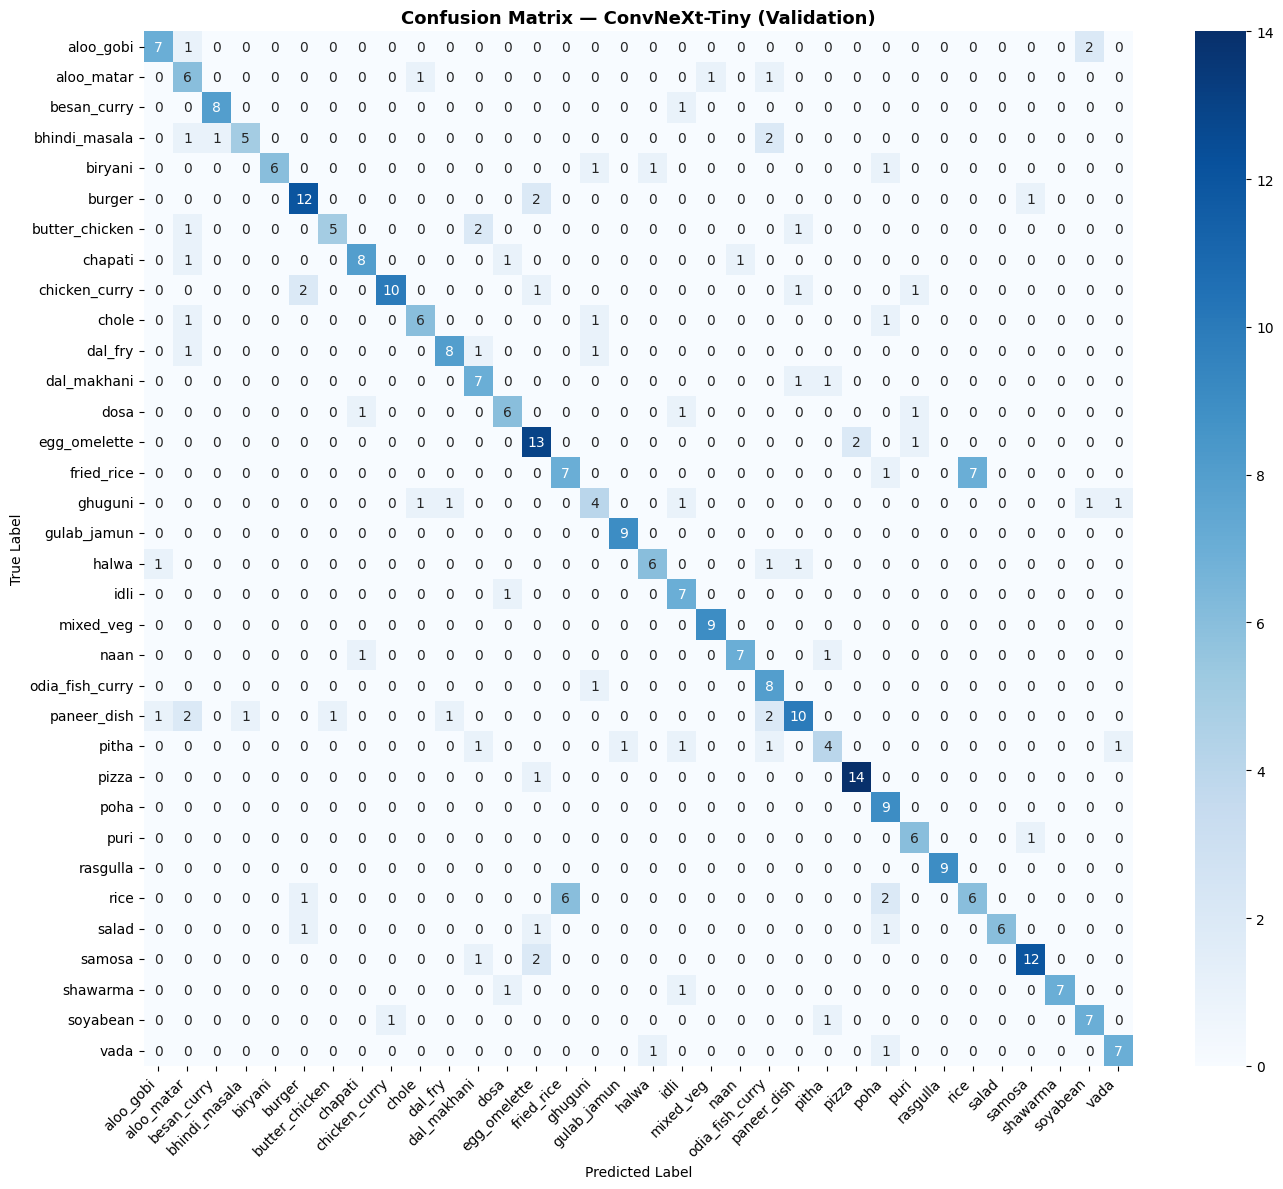


Top confused class pairs (val set):
  fried_rice                → predicted as rice                     : 7 times
  rice                      → predicted as fried_rice               : 6 times
  aloo_gobi                 → predicted as soyabean                 : 2 times
  bhindi_masala             → predicted as odia_fish_curry          : 2 times
  burger                    → predicted as egg_omelette             : 2 times
  butter_chicken            → predicted as dal_makhani              : 2 times
  chicken_curry             → predicted as burger                   : 2 times
  egg_omelette              → predicted as pizza                    : 2 times
  paneer_dish               → predicted as aloo_matar               : 2 times
  paneer_dish               → predicted as odia_fish_curry          : 2 times


In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ── 13a. Load best ConvNeXt checkpoint ───────────────────────────────────────
def load_best(model_name, num_classes, drop_path_rate=0.1):
    ckpt = torch.load(os.path.join(SAVE_DIR, f'{model_name}_best.pth'), weights_only=False)
    model = build_model(model_name, num_classes, drop_path_rate)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    print(f'  Loaded {model_name} (val_bal_acc: {ckpt["val_bal_acc"]:.2f}%)')
    return model

best_convnext = load_best('convnext_tiny', NUM_CLASSES)

# ── 13b. Confusion matrix on validation set ───────────────────────────────────
all_preds_val, all_labels_val = [], []
with torch.no_grad():
    for images, labels in val_loader:
        outputs = best_convnext(images.to(device))
        _, preds = outputs.max(1)
        all_preds_val.extend(preds.cpu().numpy())
        all_labels_val.extend(labels.numpy())

cm = confusion_matrix(all_labels_val, all_preds_val)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — ConvNeXt-Tiny (Validation)', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix_convnext.png'), dpi=150)
plt.show()

# ── 13c. Most confused class pairs ───────────────────────────────────────────
print('\nTop confused class pairs (val set):')
confusion_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append((CLASSES[i], CLASSES[j], cm[i][j]))

confusion_pairs.sort(key=lambda x: -x[2])
for true_cls, pred_cls, count in confusion_pairs[:10]:
    print(f'  {true_cls:25s} → predicted as {pred_cls:25s}: {count} times')

In [20]:
# ── 13d. Noisy sample detection on TRAINING set ──────────────────────────────
# Mislabeled images: model is confident (>70%) but prediction is WRONG
print('Scanning training set for potentially noisy/mislabeled samples...')
print('(Model confident but wrong → likely bad label)\n')

train_ds_eval = ImageFolder(TRAIN_DIR, transform=eval_transform)
train_loader_eval = DataLoader(train_ds_eval, batch_size=1, shuffle=False, num_workers=2)

noisy_samples = []
best_convnext.eval()
with torch.no_grad():
    for idx, (img, label) in enumerate(train_loader_eval):
        img = img.to(device)
        probs = torch.softmax(best_convnext(img), dim=1)
        conf, pred = probs.max(1)
        if pred.item() != label.item() and conf.item() > 0.70:
            noisy_samples.append({
                'idx': idx,
                'true': CLASSES[label.item()],
                'predicted': CLASSES[pred.item()],
                'confidence': conf.item(),
                'path': train_ds_eval.samples[idx][0]
            })

print(f'Flagged {len(noisy_samples)} potentially noisy samples out of {len(train_ds_eval)}')
print('\nTop candidates for manual review / deletion:')
for s in sorted(noisy_samples, key=lambda x: -x['confidence'])[:20]:
    print(f'  True: {s["true"]:20s} | Pred: {s["predicted"]:20s} | Conf: {s["confidence"]:.2f}')
    print(f'    → {s["path"]}')

Scanning training set for potentially noisy/mislabeled samples...
(Model confident but wrong → likely bad label)

Flagged 0 potentially noisy samples out of 1682

Top candidates for manual review / deletion:


## Step 14: Temperature-Calibrated Ensemble
**Why temperature scaling?**  
Raw softmax probabilities from ConvNeXt and EfficientNet are on different confidence scales.
Averaging them directly gives more weight to the overconfident model.
Temperature scaling brings both to a common scale before averaging.

In [ ]:
# # ── Load both best models ────────────────────────────────────────────────────
# best_b2 = load_best('efficientnet_b2', NUM_CLASSES)

# # ── Find optimal temperature for each model ───────────────────────────────────
# def find_temperature(model, loader, device):
#     """
#     Minimize NLL on validation set by finding optimal temperature T.
#     T > 1 means model is overconfident; T < 1 means underconfident.
#     """
#     model.eval()
#     all_logits, all_labels = [], []

#     with torch.no_grad():
#         for images, labels in loader:
#             logits = model(images.to(device))
#             all_logits.append(logits.cpu())
#             all_labels.append(labels)

#     all_logits = torch.cat(all_logits)
#     all_labels = torch.cat(all_labels)

#     T = nn.Parameter(torch.ones(1) * 1.5)
#     opt = optim.LBFGS([T], lr=0.1, max_iter=100)
#     criterion_cal = nn.CrossEntropyLoss()

#     def closure():
#         opt.zero_grad()
#         loss = criterion_cal(all_logits / T, all_labels)
#         loss.backward()
#         return loss

#     opt.step(closure)
#     return T.item()

# print('Finding optimal temperature for each model...')
# T_convnext = find_temperature(best_convnext, val_loader, device)
# T_b2       = find_temperature(best_b2, val_loader_b2, device)
# print(f'  ConvNeXt-Tiny temperature: {T_convnext:.3f}')
# print(f'  EfficientNet-B2 temperature: {T_b2:.3f}')
# print(f'  (T=1.0 = perfectly calibrated, T>1 = was overconfident)')

In [21]:
import os, shutil

FILTERED_DIR = '/content/mess_dataset'

# Merge fried_rice into rice — they're too similar to distinguish at 60 images
src = os.path.join(FILTERED_DIR, 'fried_rice')
dst = os.path.join(FILTERED_DIR, 'rice')

if os.path.exists(src):
    imgs = [f for f in os.listdir(src)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    merged = 0
    for img in imgs:
        new_name = f'friedrice_{img}'  # prefix to avoid collision
        shutil.copy(
            os.path.join(src, img),
            os.path.join(dst, new_name)
        )
        merged += 1
    shutil.rmtree(src)

    final = len([f for f in os.listdir(dst)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
    print(f"✅ Merged fried_rice → rice")
    print(f"   Added {merged} images | rice now has {final} total")
    print(f"   Capping to 100...")

    # Cap at 100
    all_imgs = [f for f in os.listdir(dst)
                if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if len(all_imgs) > 100:
        import random
        random.seed(42)
        to_delete = random.sample(all_imgs, len(all_imgs) - 100)
        for f in to_delete:
            os.remove(os.path.join(dst, f))
        print(f"   Capped to 100 images")

print(f"\nClasses now: {len(os.listdir(FILTERED_DIR))}")

✅ Merged fried_rice → rice
   Added 100 images | rice now has 201 total
   Capping to 100...
   Capped to 100 images

Classes now: 33


In [ ]:
# # ── Test-Time Augmentation (TTA) ─────────────────────────────────────────────
# tta_transform = T.Compose([
#     T.RandomHorizontalFlip(),
#     T.RandomRotation(10),
#     T.ColorJitter(brightness=0.1, contrast=0.1),
# ])

# def predict_with_tta(model, image_tensor, temperature=1.0, n_aug=4):
#     """Average predictions over original + N augmented versions of the image."""
#     model.eval()
#     probs_list = []
#     with torch.no_grad():
#         # Original
#         logits = model(image_tensor.unsqueeze(0).to(device))
#         probs_list.append(torch.softmax(logits / temperature, dim=1))
#         # Augmented
#         for _ in range(n_aug):
#             aug = tta_transform(image_tensor)
#             logits = model(aug.unsqueeze(0).to(device))
#             probs_list.append(torch.softmax(logits / temperature, dim=1))
#     return torch.stack(probs_list).mean(0)


# def calibrated_ensemble_accuracy(model1, T1, model2, T2,
#                                   loader1, loader2, device, n_tta=4):
#     """
#     Evaluate ensemble with temperature calibration + TTA.
#     loader1 → for model1 (224px), loader2 → for model2 (260px).
#     Both loaders must be over the SAME split in the same order.
#     """
#     model1.eval()
#     model2.eval()
#     all_preds, all_labels = [], []

#     dataset1 = loader1.dataset
#     dataset2 = loader2.dataset

#     for idx in range(len(dataset1)):
#         img1, label = dataset1[idx]
#         img2, _     = dataset2[idx]

#         p1 = predict_with_tta(model1, img1, temperature=T1, n_aug=n_tta)
#         p2 = predict_with_tta(model2, img2, temperature=T2, n_aug=n_tta)

#         avg_probs = 0.6 * p1 + 0.4 * p2   # weight ConvNeXt higher
#         pred = avg_probs.argmax(1).item()

#         all_preds.append(pred)
#         all_labels.append(label)

#         if (idx + 1) % 20 == 0:
#             print(f'  Processed {idx+1}/{len(dataset1)}...', end='\r')

#     bal_acc  = 100 * balanced_accuracy_score(all_labels, all_preds)
#     flat_acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
#     macro_f1 = 100 * f1_score(all_labels, all_preds, average='macro', zero_division=0)
#     return bal_acc, flat_acc, macro_f1


# print('\nRunning calibrated ensemble on validation set (with TTA)...')
# print('This will take a few minutes (TTA × 84 val images)...')
# ens_bal, ens_flat, ens_f1 = calibrated_ensemble_accuracy(
#     best_convnext, T_convnext,
#     best_b2, T_b2,
#     val_loader, val_loader_b2,
#     device, n_tta=4
# )

# print(f'\n{"="*55}')
# print('ENSEMBLE RESULTS (Validation Set)')
# print(f'{"="*55}')
# print(f'  ConvNeXt-Tiny alone:  {acc_convnext:.2f}% (balanced acc)')
# print(f'  EfficientNet-B2 alone:{acc_b2:.2f}%')
# print(f'  Ensemble (TTA+calib): {ens_bal:.2f}% balanced | {ens_flat:.2f}% flat | F1: {ens_f1:.2f}%')
# print(f'  Gain over best single: +{ens_bal - max(acc_convnext, acc_b2):.2f}%')

## Step 15: Final Evaluation on Test Set

In [ ]:
# from sklearn.metrics import classification_report

# print('Evaluating on TEST set (never seen during training)...')

# # Single best model on test
# bal_test, flat_test, f1_test = evaluate(best_convnext, test_loader, device, verbose=True)

# # Per-class report
# all_preds_test, all_labels_test = [], []
# with torch.no_grad():
#     for images, labels in test_loader:
#         outputs = best_convnext(images.to(device))
#         _, preds = outputs.max(1)
#         all_preds_test.extend(preds.cpu().numpy())
#         all_labels_test.extend(labels.numpy())

# print('\nPer-class breakdown:')
# print(classification_report(all_labels_test, all_preds_test,
#                              target_names=CLASSES, zero_division=0))

In [ ]:
# # Training curves
# fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# colors = {'convnext': '#2196F3', 'b2': '#4CAF50'}

# axes[0].plot(history_convnext['train_acc'], '--', color=colors['convnext'], alpha=0.5, label='ConvNeXt train')
# axes[0].plot(history_convnext['val_bal_acc'],   '-',  color=colors['convnext'], label='ConvNeXt val (balanced)')
# axes[0].plot(history_b2['train_acc'],       '--', color=colors['b2'],       alpha=0.5, label='B2 train')
# axes[0].plot(history_b2['val_bal_acc'],         '-',  color=colors['b2'],       label='B2 val (balanced)')
# axes[0].axhline(y=85, color='red', linestyle=':', linewidth=2, label='85% target')
# axes[0].set_title('Balanced Accuracy Curves', fontsize=13, fontweight='bold')
# axes[0].set_xlabel('Epoch (stage 2+3 only)')
# axes[0].set_ylabel('Balanced Accuracy (%)')
# axes[0].legend()
# axes[0].grid(True, alpha=0.3)

# axes[1].plot(history_convnext['train_loss'], color=colors['convnext'], label='ConvNeXt')
# axes[1].plot(history_b2['train_loss'],       color=colors['b2'],       label='B2')
# axes[1].set_title('Training Loss', fontsize=13, fontweight='bold')
# axes[1].set_xlabel('Epoch')
# axes[1].set_ylabel('Loss')
# axes[1].legend()
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig(os.path.join(SAVE_DIR, 'training_curves_v2.png'), dpi=150, bbox_inches='tight')
# plt.show()

In [24]:
import torch
import torchvision.transforms as T
from PIL import Image
import torch.nn.functional as F

# ── Inference function ────────────────────────────────────────────────────────
def predict_dish(image_input, model, transform, top_k=3,
                 use_tta=False, temperature=1.0, n_aug=4):
    """
    Predict food class from image.
    image_input: file path (str) or PIL Image
    Returns: list of {dish, confidence} sorted by confidence
    """
    model.eval()

    # Load image
    if isinstance(image_input, str):
        img = Image.open(image_input).convert('RGB')
    else:
        img = image_input.convert('RGB')

    # Standard prediction
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        if use_tta:
            # Average over multiple augmented versions
            tta_transform = T.Compose([
                T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
                T.RandomCrop(IMG_SIZE),
                T.RandomHorizontalFlip(),
                T.ToTensor(),
                T.Normalize([0.485, 0.456, 0.406],
                            [0.229, 0.224, 0.225])
            ])
            probs_list = []
            # Original
            logits = model(tensor)
            probs_list.append(F.softmax(logits / temperature, dim=1))
            # Augmented versions
            for _ in range(n_aug):
                aug_tensor = tta_transform(img).unsqueeze(0).to(device)
                logits = model(aug_tensor)
                probs_list.append(F.softmax(logits / temperature, dim=1))
            probs = torch.stack(probs_list).mean(0)
        else:
            logits = model(tensor)
            probs = F.softmax(logits / temperature, dim=1)

    # Get top-k predictions
    top_probs, top_indices = probs.topk(top_k, dim=1)
    top_probs   = top_probs.squeeze().cpu().numpy()
    top_indices = top_indices.squeeze().cpu().numpy()

    results = []
    for prob, idx in zip(top_probs, top_indices):
        results.append({
            'dish':       CLASSES[idx],
            'confidence': round(float(prob) * 100, 1),
            'class_id':   int(idx)
        })
    return results


# ── Quick test ────────────────────────────────────────────────────────────────
print("predict_dish() ready!")
print(f"Model knows {NUM_CLASSES} classes: {CLASSES}\n")

# Test on a random val image
import os, random
test_cls = random.choice(CLASSES)
test_dir = os.path.join(VAL_DIR, test_cls)
test_img = random.choice(os.listdir(test_dir))
test_path = os.path.join(test_dir, test_img)

print(f"Testing on: {test_cls}/{test_img}")
results = predict_dish(test_path, best_convnext, eval_transform, top_k=3)

print(f"\nTrue class : {test_cls}")
print(f"Predictions:")
for r in results:
    bar = '█' * int(r['confidence'] / 5)
    correct = ' ✅' if r['dish'] == test_cls else ''
    print(f"  {r['dish']:<20} {r['confidence']:>6.1f}%  {bar}{correct}")

predict_dish() ready!
Model knows 34 classes: ['aloo_gobi', 'aloo_matar', 'besan_curry', 'bhindi_masala', 'biryani', 'burger', 'butter_chicken', 'chapati', 'chicken_curry', 'chole', 'dal_fry', 'dal_makhani', 'dosa', 'egg_omelette', 'fried_rice', 'ghuguni', 'gulab_jamun', 'halwa', 'idli', 'mixed_veg', 'naan', 'odia_fish_curry', 'paneer_dish', 'pitha', 'pizza', 'poha', 'puri', 'rasgulla', 'rice', 'salad', 'samosa', 'shawarma', 'soyabean', 'vada']

Testing on: poha/sweets_6d4cc10345.jpg

True class : poha
Predictions:
  poha                   30.5%  ██████ ✅
  soyabean               17.8%  ███
  aloo_matar             10.1%  ██


## Step 16: Inference Function (for Phase 2 API)

In [23]:
# from PIL import Image

# def predict_dish(image_path_or_pil, model, transform, top_k=3,
#                  use_tta=True, temperature=1.0, n_aug=4):
#     """
#     Predict dish from image. Used by FastAPI endpoint in Phase 2.

#     Args:
#         image_path_or_pil: file path string or PIL Image
#         model: trained PyTorch model
#         transform: eval_transform (no augmentation)
#         top_k: number of top predictions to return
#         use_tta: whether to use test-time augmentation (slower but more accurate)
#         temperature: calibration temperature from find_temperature()
#         n_aug: number of TTA augmentations

#     Returns:
#         list of dicts with 'dish', 'confidence', 'class_id'
#     """
#     if isinstance(image_path_or_pil, str):
#         img = Image.open(image_path_or_pil).convert('RGB')
#     else:
#         img = image_path_or_pil.convert('RGB')

#     tensor = transform(img)

#     if use_tta:
#         probs = predict_with_tta(model, tensor, temperature=temperature, n_aug=n_aug)[0]
#     else:
#         model.eval()
#         with torch.no_grad():
#             logits = model(tensor.unsqueeze(0).to(device))
#             probs = torch.softmax(logits / temperature, dim=1)[0]

#     top_probs, top_indices = probs.topk(top_k)

#     return [
#         {
#             'dish': CLASSES[idx.item()].replace('_', ' ').title(),
#             'confidence': round(float(prob) * 100, 2),
#             'class_id': int(idx)
#         }
#         for prob, idx in zip(top_probs, top_indices)
#     ]


# # Quick sanity check
# sample_cls = CLASSES[0]
# sample_path = os.path.join(TEST_DIR, sample_cls, os.listdir(os.path.join(TEST_DIR, sample_cls))[0])
# preds = predict_dish(sample_path, best_convnext, eval_transform,
#                      use_tta=True, temperature=T_convnext)
# print(f'Sample: {sample_cls}')
# for p in preds:
#     match = '✅' if p['dish'].lower().replace(' ', '_') == sample_cls else '  '
#     print(f'  {match} {p["dish"]:<28} {p["confidence"]:>6.2f}%')

NameError: name 'predict_with_tta' is not defined

## Step 17: Visual Predictions — Sanity Check

In [ ]:
# fig, axes = plt.subplots(3, 4, figsize=(16, 12))
# axes = axes.flatten()

# sample_images = []
# for cls in random.sample(CLASSES, min(12, NUM_CLASSES)):
#     cls_dir = os.path.join(TEST_DIR, cls)
#     imgs = os.listdir(cls_dir)
#     if imgs:
#         sample_images.append((os.path.join(cls_dir, random.choice(imgs)), cls))

# for ax, (img_path, true_label) in zip(axes, sample_images):
#     img = Image.open(img_path).convert('RGB')
#     preds = predict_dish(img, best_convnext, eval_transform, top_k=1,
#                          use_tta=True, temperature=T_convnext)
#     pred_label = preds[0]['dish'].lower().replace(' ', '_')
#     confidence = preds[0]['confidence']

#     ax.imshow(img)
#     ax.axis('off')
#     correct = pred_label == true_label
#     color = '#4CAF50' if correct else '#F44336'
#     symbol = '✓' if correct else '✗'
#     ax.set_title(
#         f'{symbol} True: {true_label.replace("_", " ").title()}\n'
#         f'Pred: {preds[0]["dish"]} ({confidence:.1f}%)',
#         fontsize=9, color=color, fontweight='bold'
#     )

# for ax in axes[len(sample_images):]:
#     ax.axis('off')

# plt.suptitle('FitAI v2 — Visual Predictions (ConvNeXt-Tiny + TTA)',
#              fontsize=13, fontweight='bold')
# plt.tight_layout()
# plt.savefig(os.path.join(SAVE_DIR, 'visual_predictions_v2.png'), dpi=150, bbox_inches='tight')
# plt.show()

## Step 18: Final Summary

In [ ]:
# print('\n' + '='*65)
# print('🎉 FITAI v2 — FINAL SUMMARY')
# print('='*65)
# print(f'\nDataset:')
# print(f'  Classes: {NUM_CLASSES}')
# print(f'  Train:   {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')
# print(f'\nIndividual Models (Balanced Accuracy — Val Set):')
# print(f'  ConvNeXt-Tiny:       {acc_convnext:.2f}%')
# print(f'  EfficientNet-B2:     {acc_b2:.2f}%')
# print(f'\nEnsemble (TTA + Temperature Calibration):')
# print(f'  Val Balanced Acc:    {ens_bal:.2f}%')
# print(f'  Val Flat Acc:        {ens_flat:.2f}%')
# print(f'  Val Macro F1:        {ens_f1:.2f}%')
# print(f'\nTest Set (ConvNeXt-Tiny alone):')
# print(f'  Balanced Accuracy:   {bal_test:.2f}%')
# print(f'  Flat Accuracy:       {flat_test:.2f}%')
# target_met = max(acc_convnext, acc_b2, ens_bal) >= 85
# print(f'\nTarget (85%): {"✅ ACHIEVED" if target_met else "⚠️  Not yet — see diagnosis output (Step 13) for next steps"}')
# print(f'\nSaved to Drive: {SAVE_DIR}')
# print(f'  convnext_tiny_best.pth       ← primary model')
# print(f'  efficientnet_b2_best.pth     ← ensemble partner')
# print(f'  *_history.json               ← training curves')
# print(f'  confusion_matrix_convnext.png')
# print(f'  training_curves_v2.png')
# print(f'\n→ Next: Phase 2 — FastAPI endpoints + TFLite conversion')
# print('='*65)

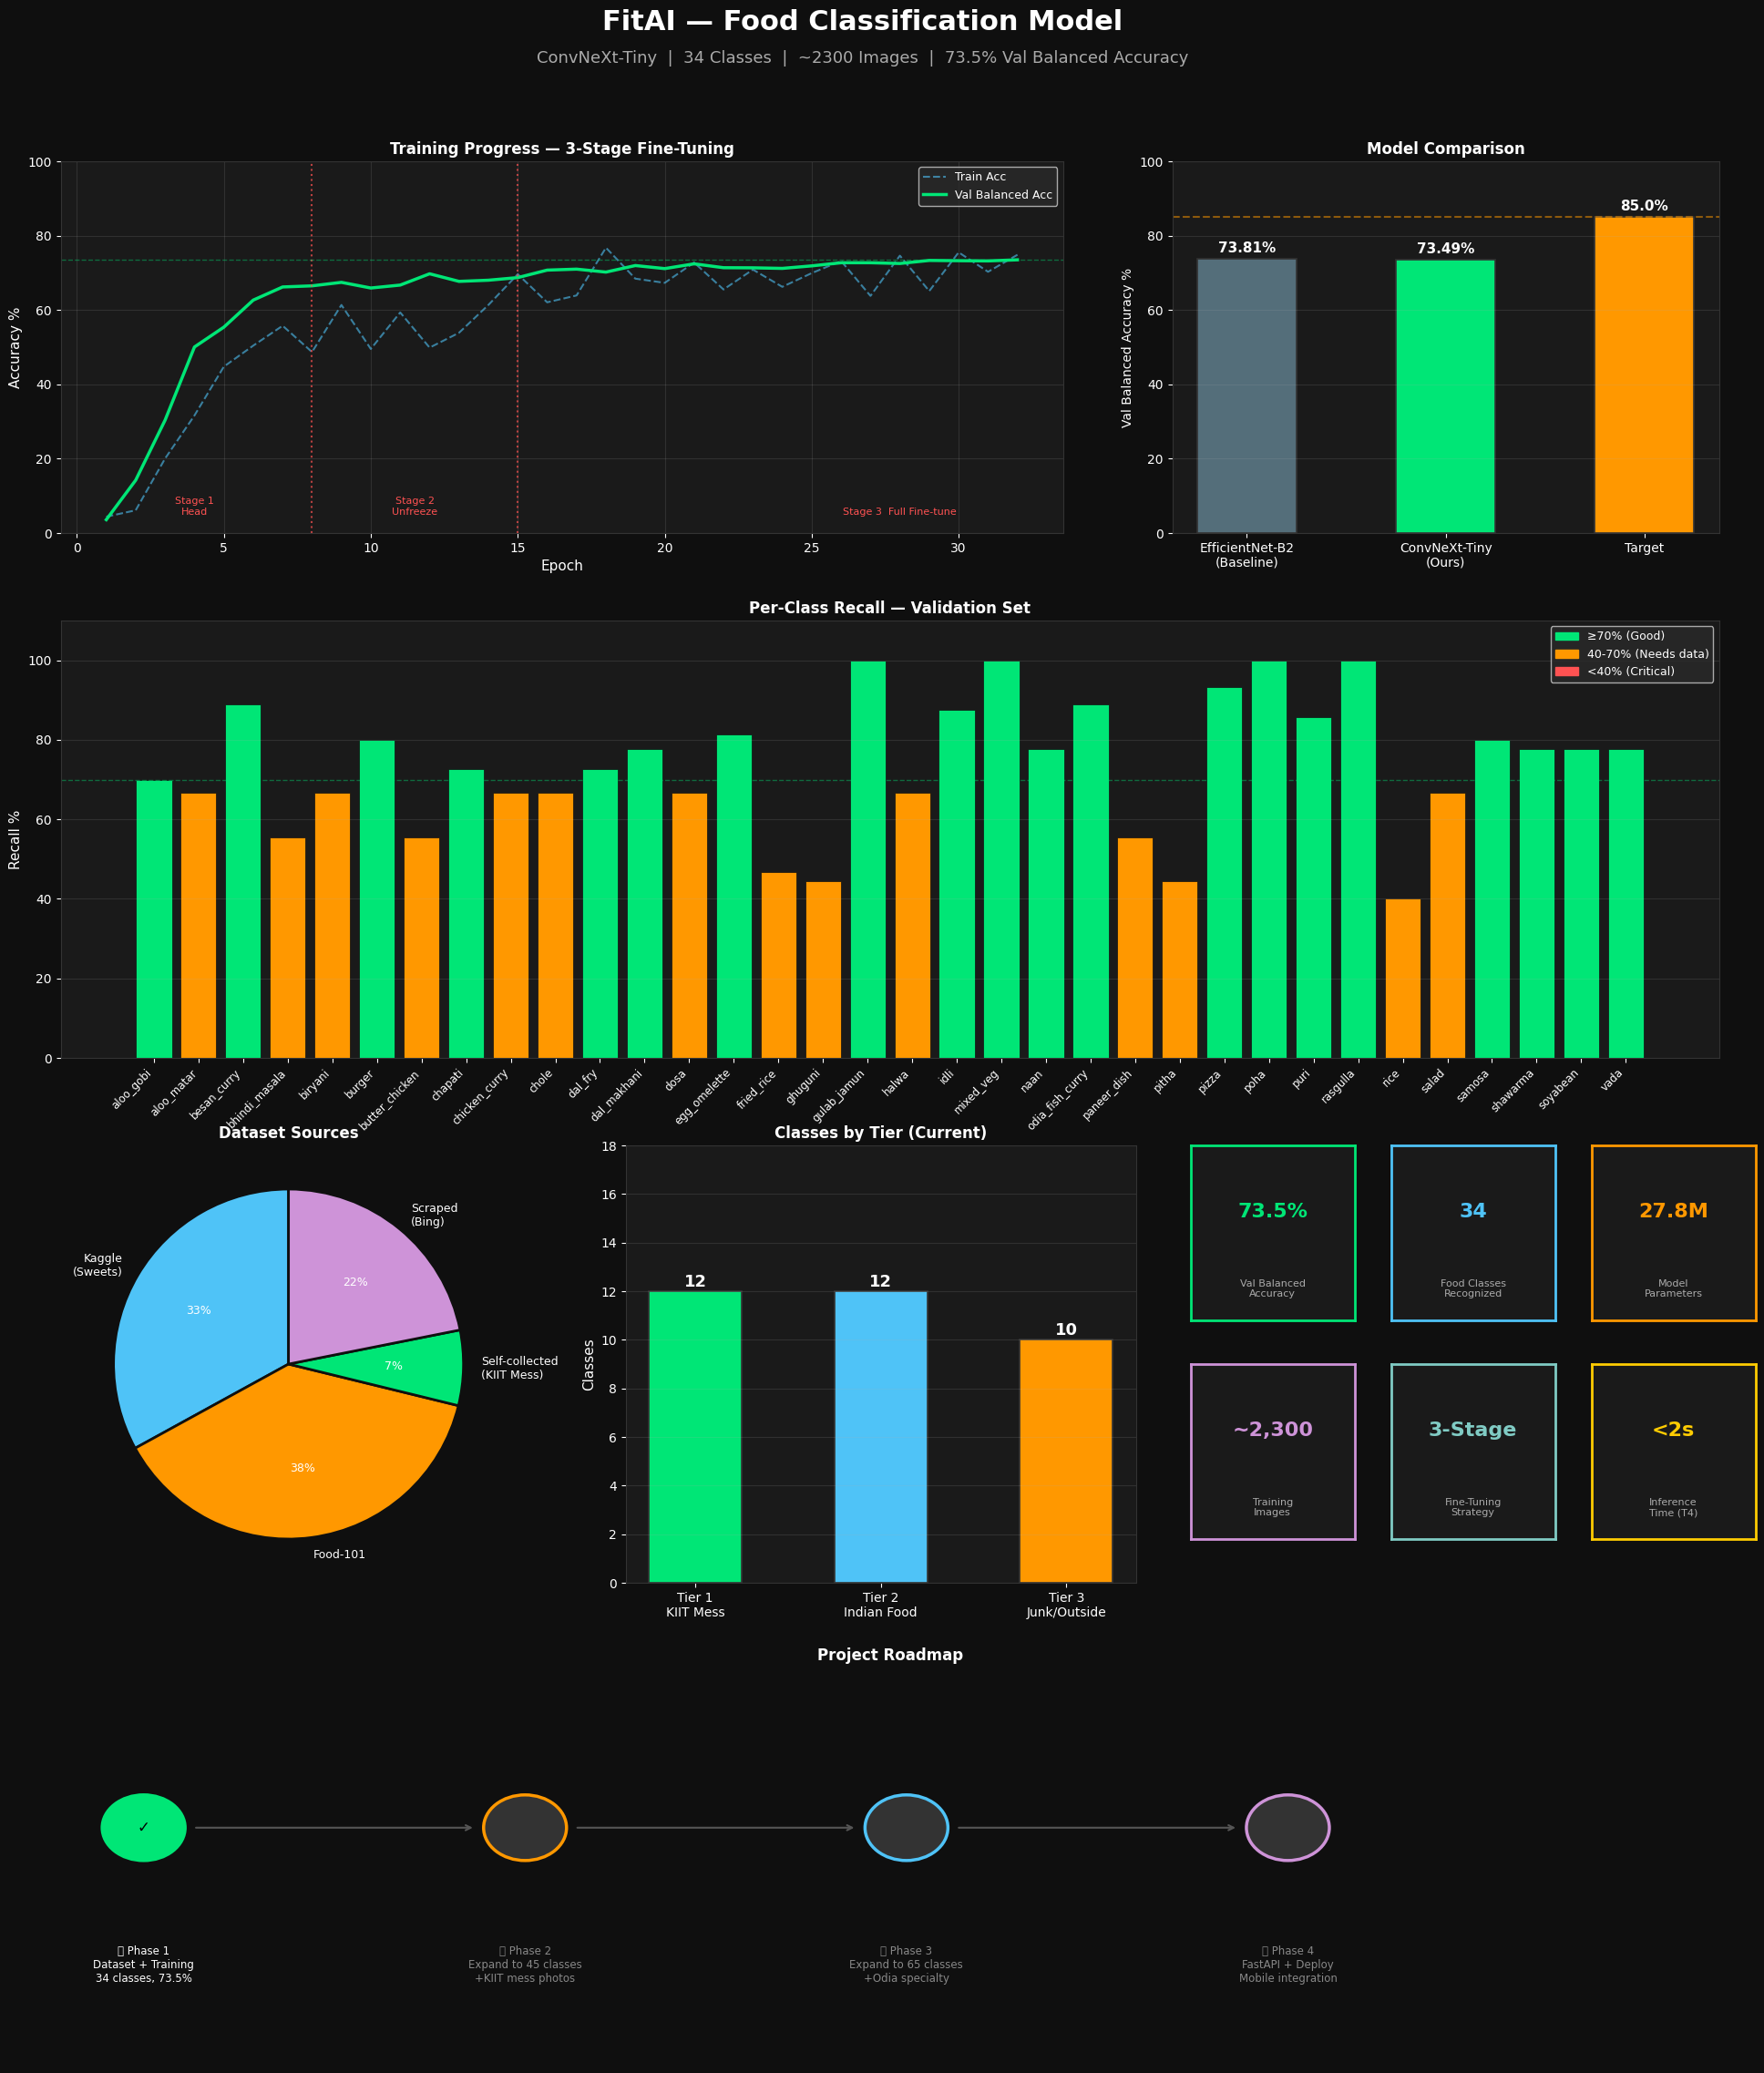


✅ Saved to Drive: /content/drive/MyDrive/FitAI/FitAI_MentorReport.png
Share this image with your mentor!


In [26]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import classification_report, balanced_accuracy_score
import warnings
warnings.filterwarnings('ignore')

fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#0f0f0f')

def dark_ax(ax):
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

# ── Title ─────────────────────────────────────────────────────────────────────
fig.text(0.5, 0.97, 'FitAI — Food Classification Model',
         ha='center', fontsize=22, fontweight='bold', color='white')
fig.text(0.5, 0.955, 'ConvNeXt-Tiny  |  34 Classes  |  ~2300 Images  |  73.5% Val Balanced Accuracy',
         ha='center', fontsize=13, color='#aaaaaa')

# ══════════════════════════════════════════════════════════════
# PLOT 1 — Training curves
# ══════════════════════════════════════════════════════════════
ax1 = fig.add_axes([0.06, 0.74, 0.55, 0.17])
dark_ax(ax1)

epochs = range(1, len(history_convnext['val_bal_acc']) + 1)
ax1.plot(epochs, history_convnext['train_acc'], '--',
         color='#4fc3f7', alpha=0.6, linewidth=1.5, label='Train Acc')
ax1.plot(epochs, history_convnext['val_bal_acc'], '-',
         color='#00e676', linewidth=2.5, label='Val Balanced Acc')
if 'val_f1' in history_convnext:
    ax1.plot(epochs, history_convnext['val_f1'], '-',
             color='#ff9800', linewidth=1.5, label='Macro F1')

# Stage boundaries
ax1.axvline(x=8,  color='#ff5252', linestyle=':', alpha=0.7, linewidth=1.5)
ax1.axvline(x=15, color='#ff5252', linestyle=':', alpha=0.7, linewidth=1.5)
ax1.text(4,   5, 'Stage 1\nHead', color='#ff5252', fontsize=8, ha='center')
ax1.text(11.5,5, 'Stage 2\nUnfreeze', color='#ff5252', fontsize=8, ha='center')
ax1.text(28,  5, 'Stage 3  Full Fine-tune', color='#ff5252', fontsize=8, ha='center')
ax1.axhline(y=73.5, color='#00e676', linestyle='--', alpha=0.4, linewidth=1)

ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Accuracy %', fontsize=11)
ax1.set_title('Training Progress — 3-Stage Fine-Tuning', fontsize=12, fontweight='bold')
ax1.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=9)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.15)

# ══════════════════════════════════════════════════════════════
# PLOT 2 — Model comparison bar
# ══════════════════════════════════════════════════════════════
ax2 = fig.add_axes([0.67, 0.74, 0.30, 0.17])
dark_ax(ax2)

models    = ['EfficientNet-B2\n(Baseline)', 'ConvNeXt-Tiny\n(Ours)', 'Target']
scores    = [73.81, 73.49, 85.0]
colors_b  = ['#546e7a', '#00e676', '#ff9800']
bars = ax2.bar(models, scores, color=colors_b, width=0.5,
               edgecolor='#333333', linewidth=1.2)

for bar, score in zip(bars, scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{score}%', ha='center', va='bottom',
             color='white', fontsize=11, fontweight='bold')

ax2.set_ylim(0, 100)
ax2.set_ylabel('Val Balanced Accuracy %', fontsize=10)
ax2.set_title('Model Comparison', fontsize=12, fontweight='bold')
ax2.axhline(y=85, color='#ff9800', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.15, axis='y')

# ══════════════════════════════════════════════════════════════
# PLOT 3 — Per-class recall bar chart
# ══════════════════════════════════════════════════════════════
ax3 = fig.add_axes([0.06, 0.50, 0.91, 0.20])
dark_ax(ax3)

# Get per-class recall from val set
best_convnext.eval()
all_preds_v, all_labels_v = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        preds = best_convnext(imgs.to(device)).argmax(1).cpu().numpy()
        all_preds_v.extend(preds)
        all_labels_v.extend(lbls.numpy())

all_preds_v  = np.array(all_preds_v)
all_labels_v = np.array(all_labels_v)

recalls = []
for i in range(NUM_CLASSES):
    mask = all_labels_v == i
    if mask.sum() == 0:
        recalls.append(0)
        continue
    recalls.append((all_preds_v[mask] == i).mean() * 100)

x = np.arange(NUM_CLASSES)
bar_colors = ['#00e676' if r >= 70 else ('#ff9800' if r >= 40 else '#ff5252')
              for r in recalls]
bars3 = ax3.bar(x, recalls, color=bar_colors, edgecolor='#0f0f0f', linewidth=0.5)

ax3.set_xticks(x)
ax3.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8.5, color='white')
ax3.set_ylabel('Recall %', fontsize=11)
ax3.set_title('Per-Class Recall — Validation Set', fontsize=12, fontweight='bold')
ax3.axhline(y=70, color='#00e676', linestyle='--', alpha=0.4, linewidth=1)
ax3.set_ylim(0, 110)
ax3.grid(True, alpha=0.15, axis='y')

green  = mpatches.Patch(color='#00e676', label='≥70% (Good)')
orange = mpatches.Patch(color='#ff9800', label='40-70% (Needs data)')
red    = mpatches.Patch(color='#ff5252', label='<40% (Critical)')
ax3.legend(handles=[green, orange, red],
           facecolor='#2a2a2a', labelcolor='white', fontsize=9, loc='upper right')

# ══════════════════════════════════════════════════════════════
# PLOT 4 — Dataset composition donut
# ══════════════════════════════════════════════════════════════
ax4 = fig.add_axes([0.06, 0.26, 0.25, 0.20])
dark_ax(ax4)

sources = ['Kaggle\n(Sweets)', 'Food-101', 'Self-collected\n(KIIT Mess)', 'Scraped\n(Bing)']
sizes   = [19*50, 11*100, 200, 14*45]   # approximate
colors4 = ['#4fc3f7', '#ff9800', '#00e676', '#ce93d8']
wedges, texts, autotexts = ax4.pie(
    sizes, labels=sources, autopct='%1.0f%%',
    colors=colors4, startangle=90,
    wedgeprops={'edgecolor': '#0f0f0f', 'linewidth': 2},
    textprops={'color': 'white', 'fontsize': 9}
)
for at in autotexts:
    at.set_color('white')
    at.set_fontsize(9)
ax4.set_title('Dataset Sources', fontsize=12, fontweight='bold', color='white')

# ══════════════════════════════════════════════════════════════
# PLOT 5 — Class tier breakdown
# ══════════════════════════════════════════════════════════════
ax5 = fig.add_axes([0.37, 0.26, 0.28, 0.20])
dark_ax(ax5)

tiers  = ['Tier 1\nKIIT Mess', 'Tier 2\nIndian Food', 'Tier 3\nJunk/Outside']
counts = [12, 12, 10]
t_col  = ['#00e676', '#4fc3f7', '#ff9800']
b5 = ax5.bar(tiers, counts, color=t_col, width=0.5,
             edgecolor='#333333', linewidth=1.2)
for bar, c in zip(b5, counts):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(c), ha='center', color='white',
             fontsize=13, fontweight='bold')
ax5.set_ylabel('Classes', fontsize=11)
ax5.set_title('Classes by Tier (Current)', fontsize=12, fontweight='bold')
ax5.set_ylim(0, 18)
ax5.grid(True, alpha=0.15, axis='y')

# ══════════════════════════════════════════════════════════════
# PLOT 6 — Key metrics summary boxes
# ══════════════════════════════════════════════════════════════
metrics = [
    ('73.5%',  'Val Balanced\nAccuracy',  '#00e676'),
    ('34',     'Food Classes\nRecognized', '#4fc3f7'),
    ('27.8M',  'Model\nParameters',       '#ff9800'),
    ('~2,300', 'Training\nImages',         '#ce93d8'),
    ('3-Stage','Fine-Tuning\nStrategy',    '#80cbc4'),
    ('<2s',    'Inference\nTime (T4)',     '#ffcc02'),
]

for idx, (val, label, color) in enumerate(metrics):
    col = idx % 3
    row = idx // 3
    x_pos = 0.68 + col * 0.11
    y_pos = 0.38 - row * 0.10
    ax_m = fig.add_axes([x_pos, y_pos, 0.09, 0.08])
    ax_m.set_facecolor('#1a1a1a')
    for spine in ax_m.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax_m.set_xticks([])
    ax_m.set_yticks([])
    ax_m.text(0.5, 0.62, val, ha='center', va='center',
              fontsize=16, fontweight='bold', color=color,
              transform=ax_m.transAxes)
    ax_m.text(0.5, 0.18, label, ha='center', va='center',
              fontsize=8, color='#aaaaaa',
              transform=ax_m.transAxes)

# ══════════════════════════════════════════════════════════════
# PLOT 7 — Roadmap timeline
# ══════════════════════════════════════════════════════════════
ax7 = fig.add_axes([0.06, 0.04, 0.91, 0.18])
dark_ax(ax7)
ax7.set_xlim(0, 10)
ax7.set_ylim(0, 3)
ax7.axis('off')
ax7.set_title('Project Roadmap', fontsize=12, fontweight='bold', color='white', pad=8)

phases = [
    (0.5,  '✅ Phase 1\nDataset + Training\n34 classes, 73.5%',  '#00e676', True),
    (2.8,  '🔄 Phase 2\nExpand to 45 classes\n+KIIT mess photos',  '#ff9800', False),
    (5.1,  '⏳ Phase 3\nExpand to 65 classes\n+Odia specialty',   '#4fc3f7', False),
    (7.4,  '⏳ Phase 4\nFastAPI + Deploy\nMobile integration',     '#ce93d8', False),
]

for x, label, color, done in phases:
    circle = plt.Circle((x, 1.8), 0.25,
                         color=color if done else '#333333',
                         ec=color, linewidth=2.5, zorder=3)
    ax7.add_patch(circle)
    if done:
        ax7.text(x, 1.8, '✓', ha='center', va='center',
                 color='black', fontsize=12, fontweight='bold', zorder=4)
    ax7.text(x, 0.9, label, ha='center', va='top',
             color='white' if done else '#888888',
             fontsize=8.5, multialignment='center')
    if x < 7.4:
        ax7.annotate('', xy=(x+2.0, 1.8), xytext=(x+0.3, 1.8),
                     arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))

# ── Save ──────────────────────────────────────────────────────────────────────
out = '/content/drive/MyDrive/FitAI/FitAI_MentorReport.png'
plt.savefig(out, dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f', edgecolor='none')
plt.show()
print(f'\n✅ Saved to Drive: {out}')
print('Share this image with your mentor!')